<a href="https://colab.research.google.com/github/mafemi/Brain-MRI-Triage-System/blob/main/Multi_Class_Brain_MRI_Triage_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Class Brain MRI Triage System Using Convolutional Neural Networks and Vision Transformer Architectures

### LIBRARY IMPORT

In [68]:
!pip install grad-cam

In [69]:
import os # For file path operations
import torch # For tensor operations and deep learning
import torch.nn as nn # For building neural network layers
import matplotlib.pyplot as plt # For plotting graphs and visualisations
import seaborn as sns # For enhanced data visualisation
import random # For reproducibility in dataset splitting
import numpy as np # For numerical operations
from PIL import Image # For image processing
from torchvision import datasets, transforms as T, models as models # For dataset handling, data transformations, and pre-trained models
from torch.utils.data import DataLoader, random_split # For loading data in batches and splitting datasets
import time
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, precision_recall_fscore_support
import cv2
import torch.optim as optim
import itertools
import pandas as pd
import torch.nn.functional as F
import shutil

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f'PyTorch version: {torch.__version__}')
# import tensorflow as tf
# print(f'TensorFlow version: {tf.__version__}')

PyTorch version: 2.11.0+cu128


### SEED FOR REPRODUCIBILITY

In [70]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # Set the seed for PyTorch to ensure reproducibility of results across different runs. This is crucial for debugging and comparing model performance, as it ensures that the same random numbers are generated for operations like weight initialisation and data shuffling.
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

print("Setting random seed 42 for reproducibility...")
seed_everything(42)

Setting random seed 42 for reproducibility...


### CONFIGURE ENVIRONMENT & DIRECTORY

In [71]:
RUNNING_IN_COLAB = True  # Set to False if running on Kaggle or locally
RUNNING_IN_KAGGLE = False

if RUNNING_IN_COLAB:
  from google.colab import drive
  # Mount Google Drive
  print("Mounting Google Drive...")
  drive.mount('/content/drive')
  BASE_DIR = '/content/drive/MyDrive/Brain_MRI_Triage_System'
  print(f"Project directory is mounted and ready: {BASE_DIR}")

else:
  if RUNNING_IN_KAGGLE:

    # ==========================================
    # KAGGLE DATA INGESTION
    # ==========================================

    # The Kaggle source
    kaggle_input = '/kaggle/input/datasets/mafemi/mri-scan'

    # The standardised destination
    standard_data_dir = os.path.join(os.getcwd(), 'Brain_MRI_Triage_System', 'data')

    if not os.path.exists(standard_data_dir):
        print(f"Routing data to your standardized directory: {standard_data_dir}...")
        shutil.copytree(kaggle_input, standard_data_dir)
        print("Done. You can now delete this cell and run your unmodified pipeline.")
    else:
        print("Data is already correctly positioned. Proceed with standard pipeline.")
  BASE_DIR = os.path.join(os.getcwd(), 'Brain_MRI_Triage_System')
  print("Running locally. Bypassing Google Drive mount.")

# Create project directory in google drive
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'data'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'logs'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'visuals'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'visuals', 'png'), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'visuals', 'svg'), exist_ok=True)


vis_dir = os.path.join(BASE_DIR, 'visuals')
png_dir = os.path.join(vis_dir, 'png')
svg_dir = os.path.join(vis_dir, 'svg')


### HARDWARE CHECK
# Verify GPU Provisioning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\n--- Hardware Check ---")
print(f"Compute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Allocated: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory is mounted and ready: /content/drive/MyDrive/Brain_MRI_Triage_System

--- Hardware Check ---
Compute Device: cuda
GPU Model: Tesla T4
VRAM Allocated: 15.64 GB


In [72]:
data_dir = os.path.join(BASE_DIR, 'data')
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'Testing')

if os.path.exists(train_dir) and os.path.exists(test_dir):
  print(f"Success: Training directory found at {train_dir}")
  print(f"Success: Testing directory found at {test_dir}")
else:
  print("ERROR: Missing required dataset directories.")
  if not os.path.exists(train_dir):
    print(f"Missing Training folder: Expected at {train_dir}")
  if not os.path.exists(test_dir):
    print(f"Missing Testing folder: Expected at {test_dir}")
  print(f"\nAction Required: Please ensure the dataset is extracted into: {data_dir}")

Success: Training directory found at /content/drive/MyDrive/Brain_MRI_Triage_System/data/Training
Success: Testing directory found at /content/drive/MyDrive/Brain_MRI_Triage_System/data/Testing


### EXPLORATORY DATA ANALYSIS


Class Distribution in Training Set:
 - meningioma: 1400 images
 - glioma: 1400 images
 - notumor: 1400 images
 - pituitary: 1400 images


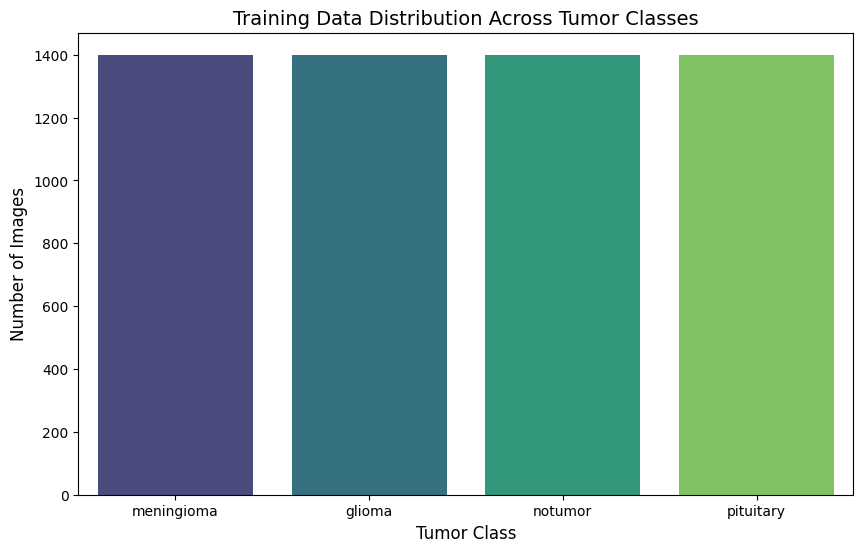

In [73]:
### EXPLORATORY DATA ANALYSIS
classes = os.listdir(train_dir)
class_counts = {}

for cls in classes:
  class_path = os.path.join(train_dir, cls)
  if os.path.isdir(class_path):
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution in Training Set:")
for cls, count in class_counts.items():
  print(f" - {cls}: {count} images")

# Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), legend=False, palette='viridis')
plt.title('Training Data Distribution Across Tumor Classes', fontsize=14)
plt.xlabel('Tumor Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Save and Show: Training Distribution
plt.savefig(os.path.join(png_dir, 'eda_1_training_distribution.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'eda_1_training_distribution.svg'), format='svg', bbox_inches='tight')
plt.show()


Class Distribution in Testing Set:
 - meningioma: 400 images
 - glioma: 400 images
 - notumor: 400 images
 - pituitary: 400 images


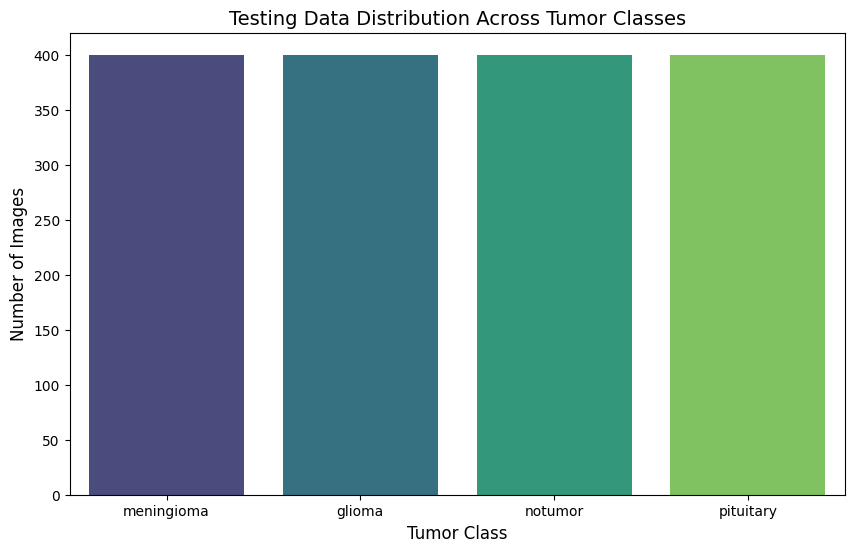

In [74]:
classes = os.listdir(train_dir)
class_counts = {}

for cls in classes:
  class_path = os.path.join(test_dir, cls)
  if os.path.isdir(class_path):
    class_counts[cls] = len(os.listdir(class_path))

print("\nClass Distribution in Testing Set:")
for cls, count in class_counts.items():
  print(f" - {cls}: {count} images")

# Distribution Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), legend=False, palette='viridis')
plt.title('Testing Data Distribution Across Tumor Classes', fontsize=14)
plt.xlabel('Tumor Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Save and Show: Testing Distribution
plt.savefig(os.path.join(png_dir, 'eda_2_testing_distribution.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'eda_2_testing_distribution.svg'), format='svg', bbox_inches='tight')
plt.show()

In [75]:
classes = sorted(os.listdir(train_dir))

widths, heights = [], []
channels = []
pixel_intensities = []
sample_images = []

histogram_bins = 50
global_pixel_counts = np.zeros(histogram_bins)
bin_edges = np.linspace(0, 256, histogram_bins + 1)


# We sample 150 images per class for pixel intensity
INTENSITY_SAMPLE_SIZE = 150

print("Scanning image dimensions, color channels, and pixel intensities... (This may take a minute)")

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if not os.path.isdir(class_path): continue

    images = os.listdir(class_path)

    # Grab a random image for the Clinical Grid
    random_img_name = random.choice(images)
    sample_images.append({
        'class': cls,
        'path': os.path.join(class_path, random_img_name)
    })

    # Select a random subset for pixel intensity analysis
    intensity_subset = set(random.sample(images, min(INTENSITY_SAMPLE_SIZE, len(images))))

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                # Image Dimensions
                widths.append(img.width)
                heights.append(img.height)
                # Color Channels ('L' = Grayscale, 'RGB' = Color)
                channels.append(img.mode)


                # Pixel Intensities (Subset only)
                if img_name in intensity_subset:
                    # Convert to grayscale array to analyze structural contrast
                    img_gray = img.convert('L')
                    img_array = np.array(img_gray).flatten()
                    counts, _ = np.histogram(img_array, bins=bin_edges)
                    global_pixel_counts += counts
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

Scanning image dimensions, color channels, and pixel intensities... (This may take a minute)


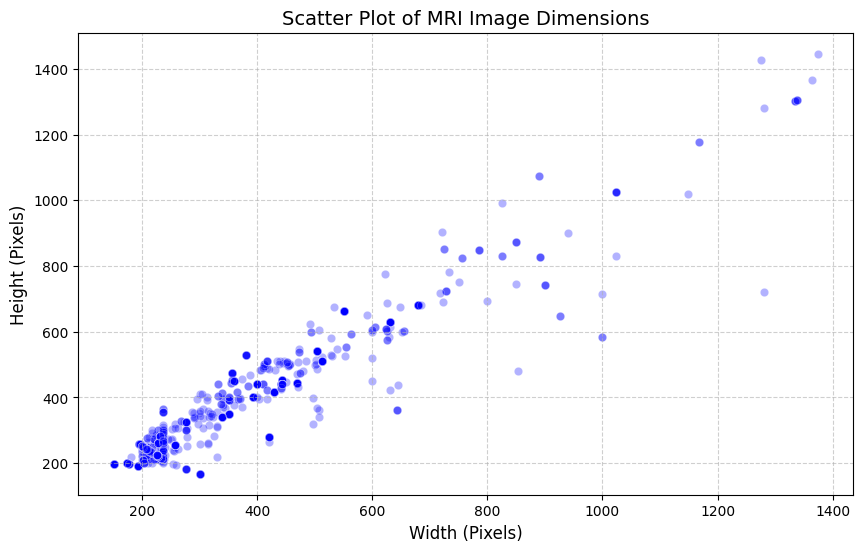

In [76]:
# Dimensional Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=widths, y=heights, alpha=0.3, color='blue')
plt.title('Scatter Plot of MRI Image Dimensions', fontsize=14)
plt.xlabel('Width (Pixels)', fontsize=12)
plt.ylabel('Height (Pixels)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Save and Show: Dimensions Scatter Plot
plt.savefig(os.path.join(png_dir, 'eda_3_dimensions_scatter.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'eda_3_dimensions_scatter.svg'), format='svg', bbox_inches='tight')
plt.show()


Color Channel Distribution across Training Set:
 - Grayscale (1-channel): 2358 images
 - P: 1 images
 - RGB (3-channel): 3238 images
 - RGBA: 3 images


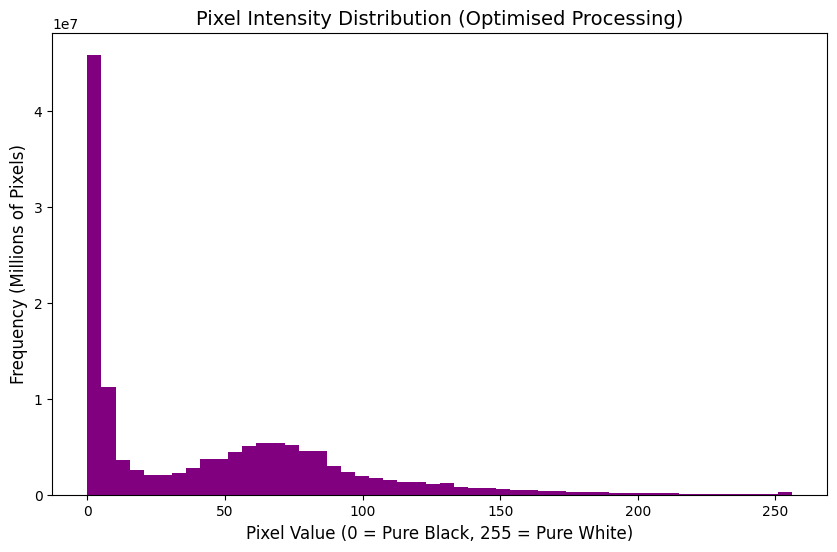

In [77]:

# Color Channel Distribution
unique_channels, counts = np.unique(channels, return_counts=True)
print("\nColor Channel Distribution across Training Set:")
for ch, count in zip(unique_channels, counts):
    ch_name = "Grayscale (1-channel)" if ch == 'L' else "RGB (3-channel)" if ch == 'RGB' else ch
    print(f" - {ch_name}: {count} images")

# Pixel Intensity Histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], global_pixel_counts, width=(256/histogram_bins), color='purple', align='edge')
plt.title('Pixel Intensity Distribution (Optimised Processing)', fontsize=14)
plt.xlabel('Pixel Value (0 = Pure Black, 255 = Pure White)', fontsize=12)
plt.ylabel('Frequency (Millions of Pixels)', fontsize=12)

# Save and Show: Pixel Intensity Histogram
plt.savefig(os.path.join(png_dir, 'eda_4_pixel_intensity.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'eda_4_pixel_intensity.svg'), format='svg', bbox_inches='tight')
plt.show()

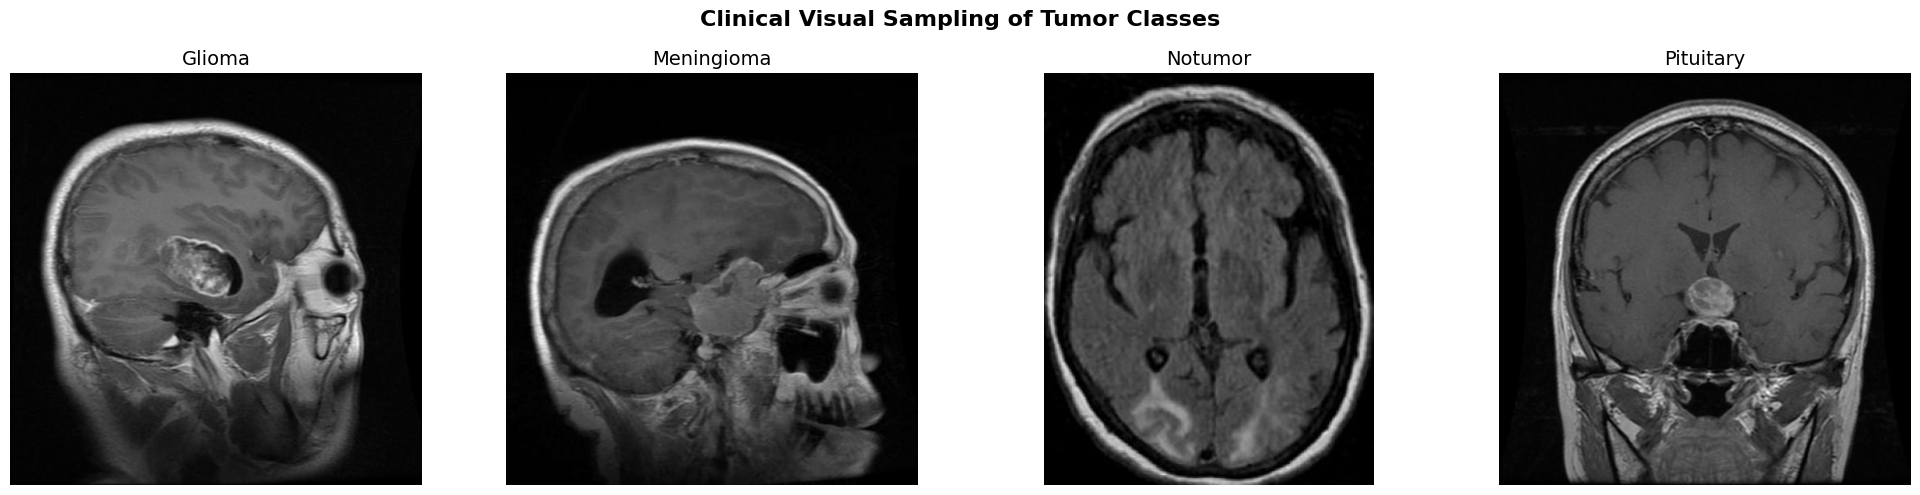

In [78]:
# Clinical Visual Grid
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Clinical Visual Sampling of Tumor Classes', fontsize=16, weight='bold')

for ax, item in zip(axes, sample_images):
    img = Image.open(item['path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(item['class'].capitalize(), fontsize=14)
    ax.axis('off')

plt.tight_layout()

# Save and Show: Clinical Grid
plt.savefig(os.path.join(png_dir, 'eda_5_clinical_grid.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'eda_5_clinical_grid.svg'), format='svg', bbox_inches='tight')
plt.show()

### DATA PREPARATION

In [79]:
class StrictBrainMaskAndCrop(object):
    """
    Advanced PyTorch Transform:
    1. Masks out all background noise.
    2. Crops tightly to the brain.
    3. Pads the image into a perfect square to prevent squishing during resize.
    """
    def __call__(self, img):
        img_np = np.array(img)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

        # Smarter Blurring
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # Otsu's Thresholding: Automatically finds the best lighting cut-off for EVERY image
        _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Morphological Closing: Acts like a net to fill in dark holes (tumors) so they aren't erased
        kernel = np.ones((7, 7), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

        contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return img

        c = max(contours, key=cv2.contourArea)

        # ANATOMICAL MASKING (Force background to pure black)
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [c], -1, 255, -1)
        img_masked = cv2.bitwise_and(img_np, img_np, mask=mask)

        # TIGHT CROP
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])

        margin = 10
        cropped_img = img_masked[
            max(0, extTop[1]-margin) : min(img_masked.shape[0], extBot[1]+margin),
            max(0, extLeft[0]-margin) : min(img_masked.shape[1], extRight[0]+margin)
        ]

        if cropped_img.size == 0:
            return img

        # SQUARE PADDING (Prevents Aspect Ratio Squishing)
        h, w = cropped_img.shape[:2]
        max_side = max(h, w)
        top = (max_side - h) // 2
        bottom = max_side - h - top
        left = (max_side - w) // 2
        right = max_side - w - left

        # Pad with pure black to make it a perfect square
        squared_img = cv2.copyMakeBorder(cropped_img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0])

        return Image.fromarray(squared_img)

In [80]:
# IMAGE TRANSFORMATIONS
# We standardise all images to RGB and resize to 224x224 for model compatibility, as well as applying ImageNet normalisation since we will be using a pretrained model.
# The augmentation techniques (RandomHorizontalFlip and RandomRotation) are applied with a 50% chance to increase the diversity of the training data, which can help the model generalise better to unseen data. The normalization step ensures that the pixel values are scaled appropriately for the pretrained model's expectations.
train_transforms = T.Compose([
    T.Lambda(lambda img: img.convert('RGB')),
    StrictBrainMaskAndCrop(),                  # Advanced crop tool
    T.Resize((224, 224)),                      # Now resizes perfectly without squishing
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing/Validation transforms strictly resize and normalise (NO augmentation)
# We maintain the same RGB conversion, resizing, and normalisation to ensure that the evaluation data is processed in a consistent manner with the training data, minus the augmentation which is only applied during training to enhance generalisation.
eval_transforms = T.Compose([
    T.Lambda(lambda img: img.convert('RGB')),
    StrictBrainMaskAndCrop(),                  # <-- The new advanced tool
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

--- Testing the New Anatomical Mask & Crop ---


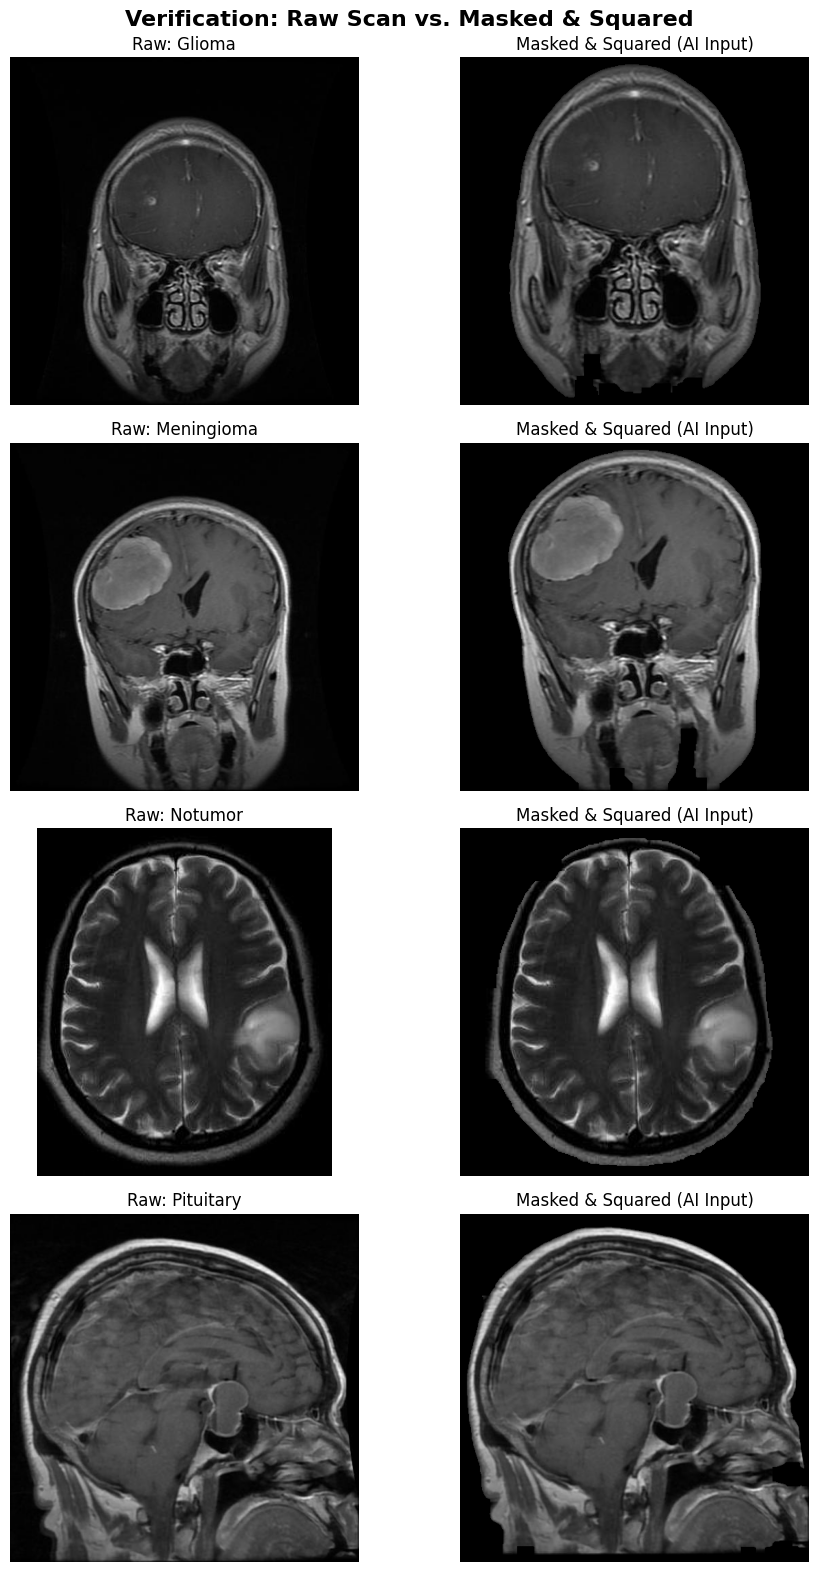

In [81]:
# ==========================================
# VISUALIZING THE NEW TRANSFORM
# ==========================================

print("--- Testing the New Anatomical Mask & Crop ---")
test_transform = StrictBrainMaskAndCrop()

# Grab one random image from each class
sample_images = []
classes = sorted(os.listdir(train_dir))
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        sample_images.append((cls, os.path.join(class_path, img_name)))

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle('Verification: Raw Scan vs. Masked & Squared', fontsize=16, weight='bold')

for row, (cls, img_path) in enumerate(sample_images):
    # Load raw image
    raw_img = Image.open(img_path).convert('RGB')

    # Apply our new strict mask
    processed_img = test_transform(raw_img)

    # Plot Raw
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"Raw: {cls.capitalize()}")
    axes[row, 0].axis('off')

    # Plot Processed
    axes[row, 1].imshow(processed_img)
    axes[row, 1].set_title(f"Masked & Squared (AI Input)")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [82]:
# DATASET SPLITTING (Train / Validation)
# Load the full training directory, which contains all the images and their corresponding labels. This dataset will be used to create both the training and validation sets. By binding the transform recipes at this stage, we ensure that when the DataLoader eventually calls for the images, data augmentation is exclusively executed on the training subset after the split, while the validation subset will be transformed separately without augmentation.
base_train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
base_val_dataset = datasets.ImageFolder(root=train_dir, transform=eval_transforms)

# Calculate the 80/20 split mathematically to ensure we have a clear separation of training and validation data, which is crucial for unbiased model evaluation. By using a fixed random seed, we guarantee that the split is reproducible across different runs, allowing for consistent results and easier debugging.
val_size = int(0.2 * len(base_train_dataset))
train_size = len(base_train_dataset) - val_size

# Create a strictly locked random generator specifically for the split
split_generator = torch.Generator().manual_seed(42)

# Generate a single, locked list of shuffled indices (e.g., Image 402, Image 12...)
indices = torch.randperm(len(base_train_dataset), generator=split_generator).tolist()

# Slice the indices cleanly. No overlap is mathematically possible.
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Split the dataset using the locked random seed for reproducibility and to ensure that the training and validation sets are mutually exclusive, which is essential for an unbiased evaluation of the model's performance on unseen data. By creating separate datasets for training and validation, we can apply different transformations (augmentation for training and no augmentation for validation) to better simulate real-world conditions during model evaluation.
train_dataset = torch.utils.data.Subset(base_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(base_val_dataset, val_indices)

# Load the separate Testing directory
test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transforms)

In [83]:
# DATALOADERS (Batching for the GPU)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Data Engineering Complete:")
print(f" - Training Set: {len(train_dataset)} images (Batches: {len(train_loader)})")
print(f" - Validation Set: {len(val_dataset)} images (Batches: {len(val_loader)})")
print(f" - Testing Set: {len(test_dataset)} images (Batches: {len(test_loader)})")

Data Engineering Complete:
 - Training Set: 4480 images (Batches: 140)
 - Validation Set: 1120 images (Batches: 35)
 - Testing Set: 1600 images (Batches: 50)


---
# ResNet-50
---

### RESNET-50 MODEL ADAPTATION

In [84]:
print("Initialising and Adapting ResNet50...")
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

Initialising and Adapting ResNet50...


In [85]:
# Freeze the convolution layers (Feature Extractor)
for param in resnet50.parameters():
    param.requires_grad = False

# Replace the final classification head
# ResNet50's default final layer was built for 1000 ImageNet classes. We need 4.
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)


# Send the model to the GPU
resnet50 = resnet50.to(device)
print("ResNet50 successfully adapted and loaded onto:", device)

ResNet50 successfully adapted and loaded onto: cuda


### ResNet-50 MODEL TRAINING

In [86]:
print("\n--- Starting ResNet50 Model Training ---")

# Define the Loss and the Optimiser
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(resnet50.fc.parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

best_val_acc = 0.0
# We name it 'best_weights' to distinguish it from a standard end-of-loop save
model_save_path_res = os.path.join(BASE_DIR, 'models', 'resnet50_best_weights_v1.pth')

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    resnet50.train() # Unlocks the brain for learning
    running_loss, correct_train, total_train = 0.0, 0, 0

    # Pull batches of 32 from the conveyor belt
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device) # Move data to device

        optimiser.zero_grad() # Wipe the whiteboard clean from the last batch

        outputs = resnet50(inputs) # Forward pass: Model makes a guess
        loss = criterion(outputs, labels) # The judge calculates the error

        loss.backward() # Backward pass: Calculate how to fix the error
        optimiser.step() # Apply the fixes to the brain

        # Track the math for graphs later
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # VALIDATION
    resnet50.eval() # Locks the brain. No learning allowed.
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad(): # Disables PyTorch's memory tracking to save VRAM
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    if epoch_val_acc > best_val_acc:
        print(f" *** New Peak! Validation Accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving Model! ***")
        best_val_acc = epoch_val_acc
        # Save the weights immediately while they are at their peak
        torch.save(resnet50.state_dict(), model_save_path_res)

    # Save the stats for this epoch
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")


--- Starting ResNet50 Model Training ---
Starting Training Engine for 10 Epochs on cuda...
Starting Training Engine for 10 Epochs on cuda...
 *** New Peak! Validation Accuracy improved from 0.0000 to 0.8143. Saving Model! ***
Epoch [1/10] (50s) - Train Loss: 0.6575, Train Acc: 0.7458 | Val Loss: 0.4805, Val Acc: 0.8143
 *** New Peak! Validation Accuracy improved from 0.8143 to 0.8393. Saving Model! ***
Epoch [2/10] (50s) - Train Loss: 0.5067, Train Acc: 0.8109 | Val Loss: 0.4509, Val Acc: 0.8393
 *** New Peak! Validation Accuracy improved from 0.8393 to 0.8705. Saving Model! ***
Epoch [3/10] (49s) - Train Loss: 0.4602, Train Acc: 0.8228 | Val Loss: 0.3483, Val Acc: 0.8705
Epoch [4/10] (51s) - Train Loss: 0.4294, Train Acc: 0.8350 | Val Loss: 0.3581, Val Acc: 0.8545
Epoch [5/10] (48s) - Train Loss: 0.4190, Train Acc: 0.8391 | Val Loss: 0.3813, Val Acc: 0.8509
Epoch [6/10] (48s) - Train Loss: 0.3897, Train Acc: 0.8480 | Val Loss: 0.3858, Val Acc: 0.8554
Epoch [7/10] (49s) - Train Loss: 

### ResNet-50 LEARNING EVALUATION

Generating Learning Curves...


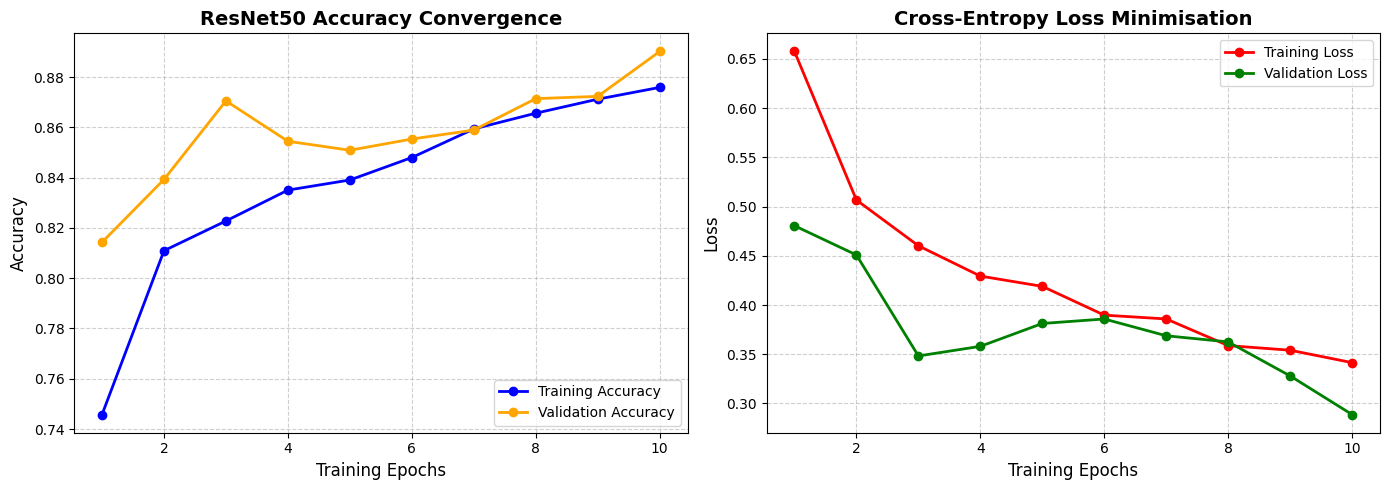

In [87]:
print("Generating Learning Curves...")

# GENERATE VISUALS
plt.figure(figsize=(14, 5))

# Accuracy Convergence Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Training Accuracy', marker='o', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o', color='orange', linewidth=2)
plt.title('ResNet50 Accuracy Convergence', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Minimisation Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', marker='o', color='red', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='green', linewidth=2)
plt.title('Cross-Entropy Loss Minimisation', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and Show: Learning Curves
plt.savefig(os.path.join(png_dir, 'resnet50_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'resnet50_learning_curves.svg'), format='svg', bbox_inches='tight')
plt.show()


### FINAL ResNet-50 MODEL TESTING

In [88]:
print("\n--- Starting ResNet-50 Model Testing ---")

resnet50.load_state_dict(torch.load(model_save_path_res))

# Lock the model for final inference (No learning allowed)
resnet50.eval()

test_loss, correct_test, total_test = 0.0, 0, 0
all_preds = []
all_labels = []

# Inference time tracking
res_total_inference_time = 0.0

print(f"Running Inference on Unseen Testing Set ({len(test_dataset)} images)...")

# Run the Test
with torch.no_grad(): # Disable memory tracking for pure speed
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        outputs = resnet50(inputs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        res_total_inference_time += (end_time - start_time)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        # Store predictions and true labels for the Confusion Matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy_res = correct_test / total_test
res_avg_latency_ms = (res_total_inference_time / total_test) * 1000
print(f"\nRESNET-50 FINAL TEST ACCURACY: {test_accuracy_res * 100:.2f}%")
print(f"RESNET-50 Total GPU Inference Time: {res_total_inference_time:.4f} seconds")
print(f"RESNET-50 Average Inference Latency per Scan: {res_avg_latency_ms:.2f} milliseconds\n")


--- Starting ResNet-50 Model Testing ---
Running Inference on Unseen Testing Set (1600 images)...

RESNET-50 FINAL TEST ACCURACY: 84.81%
RESNET-50 Total GPU Inference Time: 4.9994 seconds
RESNET-50 Average Inference Latency per Scan: 3.12 milliseconds



### ResNet-50 MODEL CLINICAL EVALUATION

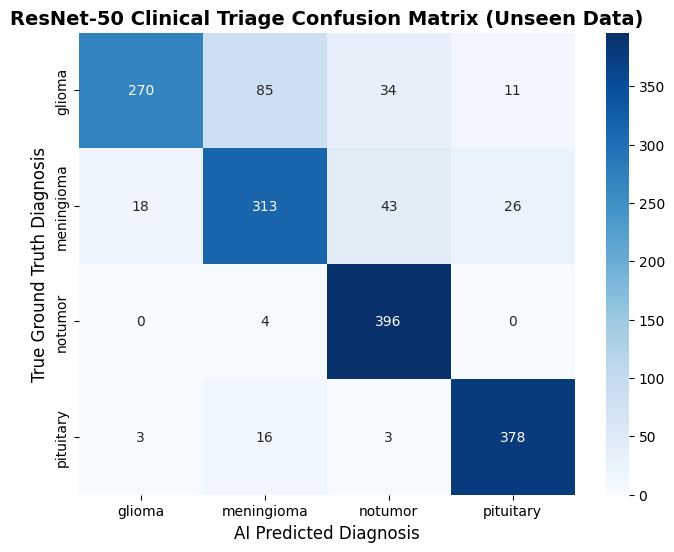


--- ResNet-50 Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.93      0.68      0.78       400
  meningioma       0.75      0.78      0.77       400
     notumor       0.83      0.99      0.90       400
   pituitary       0.91      0.94      0.93       400

    accuracy                           0.85      1600
   macro avg       0.85      0.85      0.84      1600
weighted avg       0.85      0.85      0.84      1600



In [89]:
# GENERATE CLINICAL METRICS
class_names = test_dataset.classes # Automatically grabs: glioma, meningioma, notumor, pituitary

# The Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet-50 Clinical Triage Confusion Matrix (Unseen Data)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the final thesis visual
plt.savefig(os.path.join(png_dir, 'resnet50_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'resnet50_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

# The Classification Report (Precision, Recall, F1-Score)
print("\n--- ResNet-50 Detailed Clinical Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

---
# EfficientNet-B0
---

### EfficientNet-B0 MODEL ADAPTATION

In [90]:
print("Initialising and Adapting EfficientNet-B0...")
# Load the pre-trained EfficientNet-B0 weights
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

Initialising and Adapting EfficientNet-B0...


In [91]:
# Freeze the convolution layers (Feature Extractor)
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace the final classification head
# Note: EfficientNet's classifier sequence places the Linear layer at index [1]
num_ftrs = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)

# Send the model to the GPU
efficientnet = efficientnet.to(device)
print("EfficientNet-B0 successfully adapted and loaded onto:", device)

EfficientNet-B0 successfully adapted and loaded onto: cuda


### EfficientNet-B0 MODEL TRAINING

In [92]:
print("\n--- Starting EfficientNet-B0 Model Training ---")

criterion = nn.CrossEntropyLoss()
# Target the specific classifier parameters for EfficientNet
optimiser = optim.Adam(efficientnet.classifier[1].parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Checkpointing Initialisation
best_val_acc = 0.0
model_save_path_eff = os.path.join(BASE_DIR, 'models', 'efficientnet_best_weights_v1.pth')

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    efficientnet.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = efficientnet(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # VALIDATION
    efficientnet.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = efficientnet(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # MODEL CHECKPOINTING (Saving the Peak)
    if epoch_val_acc > best_val_acc:
        print(f" *** New Peak! Validation Accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving Model! ***")
        best_val_acc = epoch_val_acc
        torch.save(efficientnet.state_dict(), model_save_path_eff)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")
print(f"Highest Validation Accuracy achieved: {best_val_acc * 100:.2f}%\n")


--- Starting EfficientNet-B0 Model Training ---
Starting Training Engine for 10 Epochs on cuda...
 *** New Peak! Validation Accuracy improved from 0.0000 to 0.8527. Saving Model! ***
Epoch [1/10] (45s) - Train Loss: 0.5600, Train Acc: 0.7913 | Val Loss: 0.3705, Val Acc: 0.8527
 *** New Peak! Validation Accuracy improved from 0.8527 to 0.8786. Saving Model! ***
Epoch [2/10] (45s) - Train Loss: 0.3928, Train Acc: 0.8549 | Val Loss: 0.3079, Val Acc: 0.8786
 *** New Peak! Validation Accuracy improved from 0.8786 to 0.8946. Saving Model! ***
Epoch [3/10] (45s) - Train Loss: 0.3623, Train Acc: 0.8665 | Val Loss: 0.2661, Val Acc: 0.8946
Epoch [4/10] (46s) - Train Loss: 0.3107, Train Acc: 0.8801 | Val Loss: 0.2482, Val Acc: 0.8938
 *** New Peak! Validation Accuracy improved from 0.8946 to 0.8982. Saving Model! ***
Epoch [5/10] (45s) - Train Loss: 0.3029, Train Acc: 0.8848 | Val Loss: 0.2455, Val Acc: 0.8982
Epoch [6/10] (44s) - Train Loss: 0.2939, Train Acc: 0.8902 | Val Loss: 0.2643, Val Acc

### EfficientNet-B0 LEARNING EVALUATION

Generating Learning Curves for EfficientNet-B0...


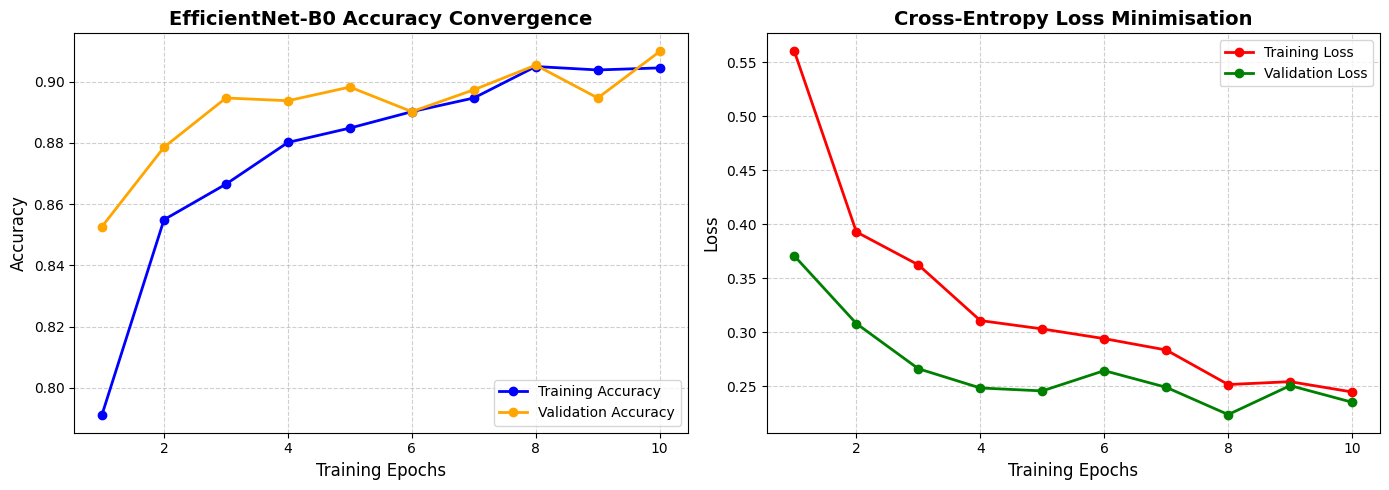

In [93]:
print("Generating Learning Curves for EfficientNet-B0...")

# GENERATE VISUALS
plt.figure(figsize=(14, 5))

# Accuracy Convergence Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Training Accuracy', marker='o', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o', color='orange', linewidth=2)
plt.title('EfficientNet-B0 Accuracy Convergence', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Minimisation Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', marker='o', color='red', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='green', linewidth=2)
plt.title('Cross-Entropy Loss Minimisation', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and Show: Learning Curves
plt.savefig(os.path.join(png_dir, 'efficientnet_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'efficientnet_learning_curves.svg'), format='svg', bbox_inches='tight')
plt.show()

### FINAL EfficientNet-B0 MODEL TESTING

In [94]:
print("\n--- Starting EfficientNet-B0 Model Testing ---")

# Explicitly load the peak checkpoint file
efficientnet.load_state_dict(torch.load(model_save_path_eff))
efficientnet.eval()

test_loss, correct_test, total_test = 0.0, 0, 0
all_preds_eff = []
all_labels_eff = []

# Inference time tracking
eff_total_inference_time = 0.0

print(f"Running Inference on Unseen Testing Set ({len(test_dataset)} images)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        outputs = efficientnet(inputs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        # Accumulate total GPU time
        eff_total_inference_time += (end_time - start_time)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds_eff.extend(predicted.cpu().numpy())
        all_labels_eff.extend(labels.cpu().numpy())

test_accuracy_eff = correct_test / total_test
eff_avg_latency_ms = (eff_total_inference_time / total_test) * 1000
print(f"\nEFFICIENTNET-B0 FINAL TEST ACCURACY: {test_accuracy_eff * 100:.2f}%\n")
print(f"EFFICIENTNET-B0 Total GPU Inference Time: {eff_total_inference_time:.4f} seconds")
print(f"EFFICIENTNET-B0 Average Inference Latency per Scan: {eff_avg_latency_ms:.2f} milliseconds\n")


--- Starting EfficientNet-B0 Model Testing ---
Running Inference on Unseen Testing Set (1600 images)...

EFFICIENTNET-B0 FINAL TEST ACCURACY: 87.00%

EFFICIENTNET-B0 Total GPU Inference Time: 2.2100 seconds
EFFICIENTNET-B0 Average Inference Latency per Scan: 1.38 milliseconds



### FINAL EfficientNet-B0 MODEL CLINICAL EVALUATION

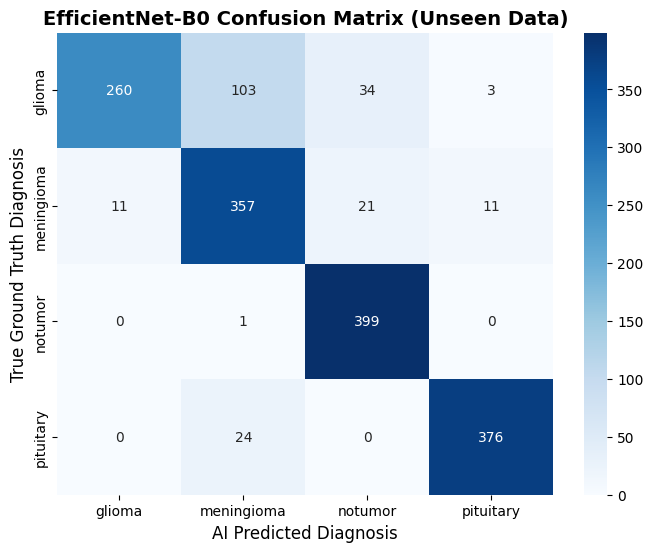


--- EfficientNet-B0 Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.96      0.65      0.77       400
  meningioma       0.74      0.89      0.81       400
     notumor       0.88      1.00      0.93       400
   pituitary       0.96      0.94      0.95       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600



In [95]:
# GENERATE CLINICAL METRICS
class_names = test_dataset.classes # Automatically grabs: glioma, meningioma, notumor, pituitary

# The Confusion Matrix Plot
cm_eff = confusion_matrix(all_labels_eff, all_preds_eff)
class_names = test_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNet-B0 Confusion Matrix (Unseen Data)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the final thesis visual
plt.savefig(os.path.join(png_dir, 'efficientnet_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'efficientnet_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

# The Classification Report
print("\n--- EfficientNet-B0 Detailed Clinical Classification Report ---")
print(classification_report(all_labels_eff, all_preds_eff, target_names=class_names))

### VISION TRANSFORMER (ViT-Base) MODEL ADAPTATION

In [96]:
print("Initialising and Adapting Vision Transformer (ViT-Base)...")

# Load the pre-trained ViT-Base (16x16 patch size)
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

Initialising and Adapting Vision Transformer (ViT-Base)...


In [97]:
# Freeze the transformer encoder layers (Feature Extractor)
for param in vit.parameters():
    param.requires_grad = False

# Replace the final classification head
# ViT's classification head is located at vit.heads.head
num_ftrs = vit.heads.head.in_features
vit.heads.head = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)

# Send the model to the GPU
vit = vit.to(device)
print("ViT-Base successfully adapted and loaded onto:", device)

ViT-Base successfully adapted and loaded onto: cuda


### ViT-Base MODEL TRAINING

In [98]:
print("\n--- Starting ViT-Base Model Training ---")

criterion = nn.CrossEntropyLoss()
# Target the specific classifier parameters for ViT
optimiser = optim.Adam(vit.heads.parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Checkpointing Initialisation
best_val_acc = 0.0
model_save_path_vit = os.path.join(BASE_DIR, 'models', 'vit_base_best_weights_v1.pth')

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    vit.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = vit(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # VALIDATION
    vit.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vit(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # MODEL CHECKPOINTING (Saving the Peak)
    if epoch_val_acc > best_val_acc:
        print(f" *** New Peak! Validation Accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving Model! ***")
        best_val_acc = epoch_val_acc
        torch.save(vit.state_dict(), model_save_path_vit)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")
print(f"Highest Validation Accuracy achieved: {best_val_acc * 100:.2f}%\n")


--- Starting ViT-Base Model Training ---
Starting Training Engine for 10 Epochs on cuda...
 *** New Peak! Validation Accuracy improved from 0.0000 to 0.8866. Saving Model! ***
Epoch [1/10] (88s) - Train Loss: 0.4177, Train Acc: 0.8408 | Val Loss: 0.2920, Val Acc: 0.8866
 *** New Peak! Validation Accuracy improved from 0.8866 to 0.9062. Saving Model! ***
Epoch [2/10] (89s) - Train Loss: 0.2470, Train Acc: 0.9085 | Val Loss: 0.2287, Val Acc: 0.9062
 *** New Peak! Validation Accuracy improved from 0.9062 to 0.9152. Saving Model! ***
Epoch [3/10] (89s) - Train Loss: 0.2037, Train Acc: 0.9192 | Val Loss: 0.2136, Val Acc: 0.9152
Epoch [4/10] (88s) - Train Loss: 0.1722, Train Acc: 0.9348 | Val Loss: 0.2733, Val Acc: 0.8902
 *** New Peak! Validation Accuracy improved from 0.9152 to 0.9321. Saving Model! ***
Epoch [5/10] (88s) - Train Loss: 0.1723, Train Acc: 0.9337 | Val Loss: 0.1771, Val Acc: 0.9321
Epoch [6/10] (89s) - Train Loss: 0.1353, Train Acc: 0.9498 | Val Loss: 0.1851, Val Acc: 0.928

### ViT-Base LEARNING EVALUATION

Generating Learning Curves for ViT-Base...


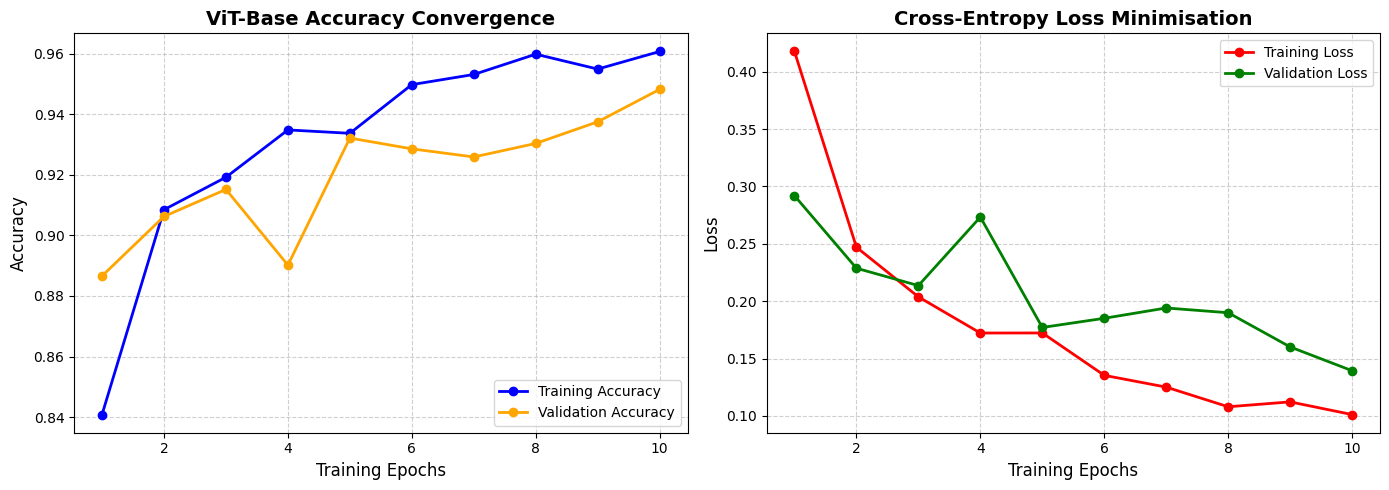

In [99]:
print("Generating Learning Curves for ViT-Base...")

# GENERATE VISUALS
plt.figure(figsize=(14, 5))

# Accuracy Convergence Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Training Accuracy', marker='o', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o', color='orange', linewidth=2)
plt.title('ViT-Base Accuracy Convergence', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Minimisation Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', marker='o', color='red', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='green', linewidth=2)
plt.title('Cross-Entropy Loss Minimisation', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and Show: Learning Curves
plt.savefig(os.path.join(png_dir, 'vit_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'vit_learning_curves.svg'), format='svg', bbox_inches='tight')
plt.show()

### FINAL ViT-Base MODEL TESTING

In [100]:
print("\n--- Starting ViT-Base Model Testing ---")

# Explicitly load the peak checkpoint file
vit.load_state_dict(torch.load(model_save_path_vit))
vit.eval()

test_loss, correct_test, total_test = 0.0, 0, 0
all_preds_vit = []
all_labels_vit = []

# Inference time tracking
vit_total_inference_time = 0.0

print(f"Running Inference on Unseen Testing Set ({len(test_dataset)} images)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        outputs = vit(inputs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        vit_total_inference_time += (end_time - start_time)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds_vit.extend(predicted.cpu().numpy())
        all_labels_vit.extend(labels.cpu().numpy())

test_accuracy_vit = correct_test / total_test
vit_avg_latency_ms = (vit_total_inference_time / total_test) * 1000

print(f"\nViT-Base FINAL TEST ACCURACY: {test_accuracy_vit * 100:.2f}%\n")
print(f"ViT-Base Total GPU Inference Time: {vit_total_inference_time:.4f} seconds")
print(f"ViT-Base Average Inference Latency per Scan: {vit_avg_latency_ms:.2f} milliseconds\n")


--- Starting ViT-Base Model Testing ---
Running Inference on Unseen Testing Set (1600 images)...

ViT-Base FINAL TEST ACCURACY: 92.31%

ViT-Base Total GPU Inference Time: 20.3455 seconds
ViT-Base Average Inference Latency per Scan: 12.72 milliseconds



### FINAL ViT-Base CLINICAL EVALUATION

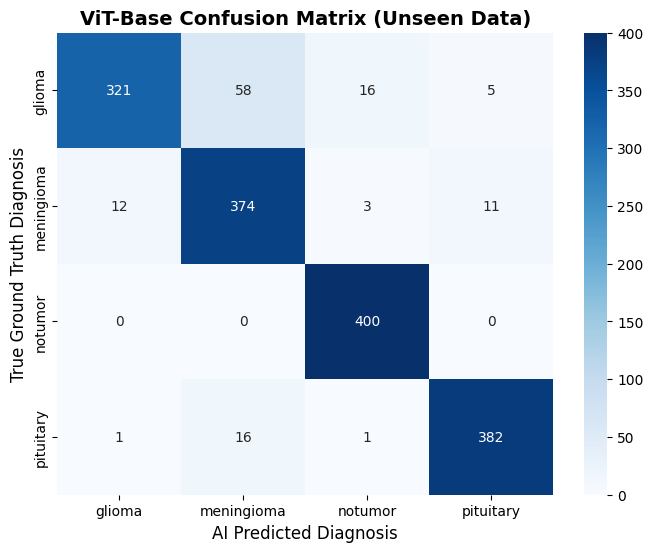


--- ViT-Base Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.96      0.80      0.87       400
  meningioma       0.83      0.94      0.88       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.96      0.95      0.96       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



In [101]:
# The Confusion Matrix Plot
cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)
class_names = test_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ViT-Base Confusion Matrix (Unseen Data)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the final thesis visual
plt.savefig(os.path.join(png_dir, 'vit_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'vit_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

# The Classification Report
print("\n--- ViT-Base Detailed Clinical Classification Report ---")
print(classification_report(all_labels_vit, all_preds_vit, target_names=class_names))

---
# SWIN TRANSFORMER
---

### SWIN TRANSFORMER MODEL ADAPTATION

In [102]:
print("Initialising and Adapting Swin Transformer...")
# Load the pre-trained Swin Transformer (Base version to match ViT-Base)
swin = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1)

Initialising and Adapting Swin Transformer...


In [103]:
# Freeze the base layers (Feature Extractor)
for param in swin.parameters():
    param.requires_grad = False

# Replace the final classification head
# Swin's classification head is accessed simply via swin.head
num_ftrs = swin.head.in_features
swin.head = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)

# Send the model to the GPU
swin = swin.to(device)
print("Swin Transformer successfully adapted and loaded onto:", device)

Swin Transformer successfully adapted and loaded onto: cuda


### SWIN TRANSFORMER MODEL TRAINING

In [104]:
print("\n--- Starting Swin Transformer Model Training ---")

criterion = nn.CrossEntropyLoss()
# Target the specific classifier parameters using the British spelling
optimiser = optim.Adam(swin.head.parameters(), lr=0.001)

# STRICT CLINICAL STANDARD: 10 Epochs
EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Checkpointing Initialisation
best_val_acc = 0.0
model_save_path_swin = os.path.join(BASE_DIR, 'models', 'swin_best_weights_v1.pth')

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    swin.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = swin(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # VALIDATION
    swin.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = swin(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # MODEL CHECKPOINTING (Saving the Peak)
    if epoch_val_acc > best_val_acc:
        print(f" *** New Peak! Validation Accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving Model! ***")
        best_val_acc = epoch_val_acc
        torch.save(swin.state_dict(), model_save_path_swin)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")
print(f"Highest Validation Accuracy achieved: {best_val_acc * 100:.2f}%\n")


--- Starting Swin Transformer Model Training ---
Starting Training Engine for 10 Epochs on cuda...
 *** New Peak! Validation Accuracy improved from 0.0000 to 0.8714. Saving Model! ***
Epoch [1/10] (82s) - Train Loss: 0.5801, Train Acc: 0.7741 | Val Loss: 0.3376, Val Acc: 0.8714
 *** New Peak! Validation Accuracy improved from 0.8714 to 0.8911. Saving Model! ***
Epoch [2/10] (86s) - Train Loss: 0.4107, Train Acc: 0.8429 | Val Loss: 0.3074, Val Acc: 0.8911
Epoch [3/10] (85s) - Train Loss: 0.3481, Train Acc: 0.8728 | Val Loss: 0.2938, Val Acc: 0.8893
 *** New Peak! Validation Accuracy improved from 0.8911 to 0.8955. Saving Model! ***
Epoch [4/10] (82s) - Train Loss: 0.3346, Train Acc: 0.8725 | Val Loss: 0.2611, Val Acc: 0.8955
 *** New Peak! Validation Accuracy improved from 0.8955 to 0.9009. Saving Model! ***
Epoch [5/10] (84s) - Train Loss: 0.3167, Train Acc: 0.8817 | Val Loss: 0.2428, Val Acc: 0.9009
Epoch [6/10] (85s) - Train Loss: 0.2908, Train Acc: 0.8955 | Val Loss: 0.2577, Val Ac

### SWIN TRANSFORMER LEARNING EVALUATION

Generating Learning Curves for Swin Transformer...


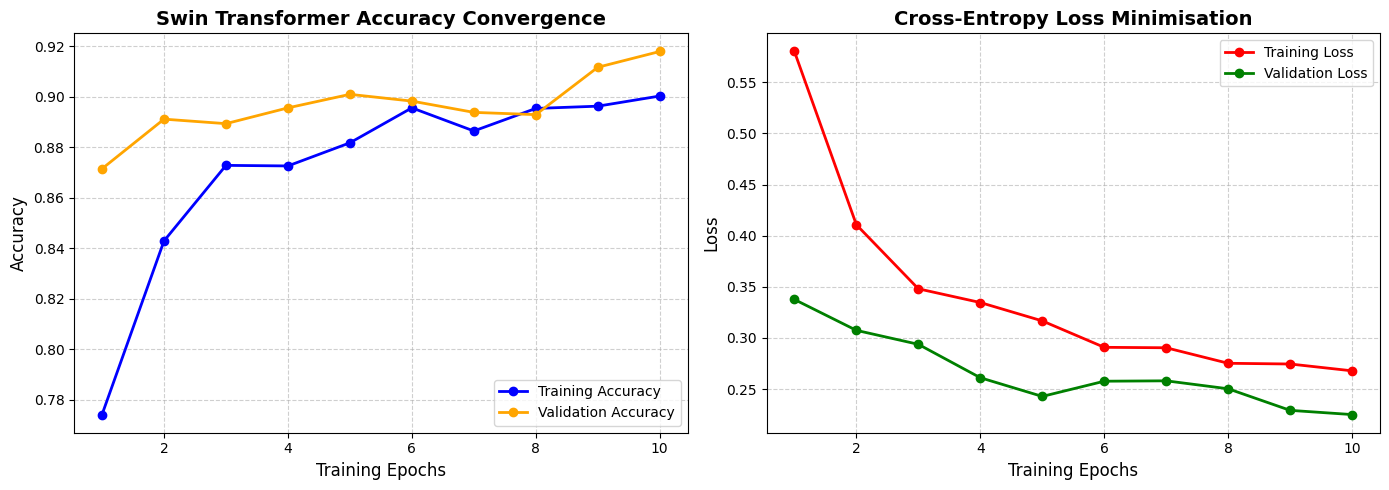

In [105]:
print("Generating Learning Curves for Swin Transformer...")

# GENERATE VISUALS
plt.figure(figsize=(14, 5))

# Accuracy Convergence Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Training Accuracy', marker='o', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o', color='orange', linewidth=2)
plt.title('Swin Transformer Accuracy Convergence', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Minimisation Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', marker='o', color='red', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='green', linewidth=2)
plt.title('Cross-Entropy Loss Minimisation', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and Show: Learning Curves
plt.savefig(os.path.join(png_dir, 'swin_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'swin_learning_curves.svg'), format='svg', bbox_inches='tight')
plt.show()

### FINAL SWIN TRANSFORMER MODEL TESTING

In [106]:
print("\n--- Starting Swin Transformer Model Testing ---")

# Explicitly load the peak checkpoint file
swin.load_state_dict(torch.load(model_save_path_swin))
swin.eval()

test_loss, correct_test, total_test = 0.0, 0, 0
all_preds_swin = []
all_labels_swin = []

# Inference time tracking
swin_total_inference_time = 0.0

print(f"Running Inference on Unseen Testing Set ({len(test_dataset)} images)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        outputs = swin(inputs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        swin_total_inference_time += (end_time - start_time)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds_swin.extend(predicted.cpu().numpy())
        all_labels_swin.extend(labels.cpu().numpy())

test_accuracy_swin = correct_test / total_test
swin_avg_latency_ms = (swin_total_inference_time / total_test) * 1000

print(f"\nSWIN TRANSFORMER FINAL TEST ACCURACY: {test_accuracy_swin * 100:.2f}%\n")
print(f"SWIN Total GPU Inference Time: {swin_total_inference_time:.4f} seconds")
print(f"SWIN Average Inference Latency per Scan: {swin_avg_latency_ms:.2f} milliseconds\n")


--- Starting Swin Transformer Model Testing ---
Running Inference on Unseen Testing Set (1600 images)...

SWIN TRANSFORMER FINAL TEST ACCURACY: 90.06%

SWIN Total GPU Inference Time: 22.2270 seconds
SWIN Average Inference Latency per Scan: 13.89 milliseconds



### FINAL SWIN TRANSFORMER CLINICAL EVALUATION

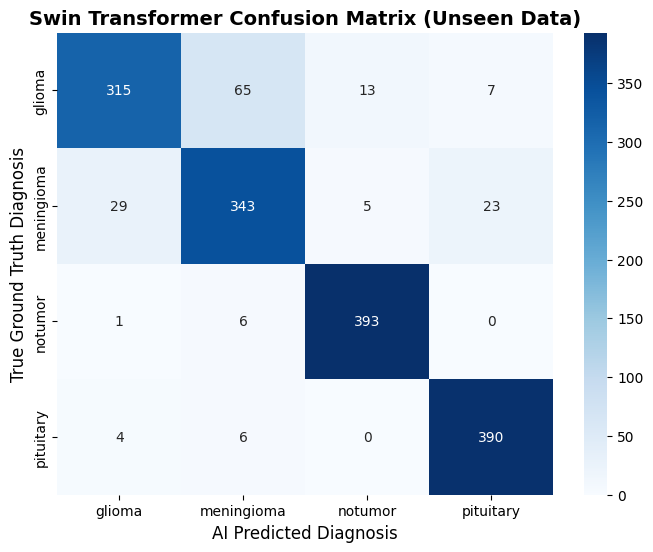


--- Swin Transformer Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.90      0.79      0.84       400
  meningioma       0.82      0.86      0.84       400
     notumor       0.96      0.98      0.97       400
   pituitary       0.93      0.97      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [107]:
# The Confusion Matrix Plot
cm_swin = confusion_matrix(all_labels_swin, all_preds_swin)
class_names = test_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm_swin, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Swin Transformer Confusion Matrix (Unseen Data)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the final thesis visual
plt.savefig(os.path.join(png_dir, 'swin_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'swin_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

# The Classification Report
print("\n--- Swin Transformer Detailed Clinical Classification Report ---")
print(classification_report(all_labels_swin, all_preds_swin, target_names=class_names))

---
# ConvNeXt
---

### CONVNEXT MODEL ADAPTATION

In [108]:
print("Initialising and Adapting ConvNeXt-Base...")
# Load the pre-trained ConvNeXt (Base version for fair comparison)
convnext = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)

Initialising and Adapting ConvNeXt-Base...


In [109]:
# Freeze the base layers (Feature Extractor)
for param in convnext.parameters():
    param.requires_grad = False

# Replace the final classification head
# ConvNeXt's classification head is a sequential block where the linear layer is at index 2
num_ftrs = convnext.classifier[2].in_features
convnext.classifier[2] = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 4) # 4 classes: Glioma, Meningioma, No Tumor, Pituitary
)

# Send the model to the GPU
convnext = convnext.to(device)
print("ConvNeXt successfully adapted and loaded onto:", device)

ConvNeXt successfully adapted and loaded onto: cuda


### ConvNeXt MODEL TRAINING

In [110]:
print("\n--- Starting ConvNeXt Model Training ---")

criterion = nn.CrossEntropyLoss()
# Target the specific classifier parameters using the British spelling
optimiser = optim.Adam(convnext.classifier[2].parameters(), lr=0.001)

EPOCHS = 10
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Checkpointing Initialisation
best_val_acc = 0.0
model_save_path_conv = os.path.join(BASE_DIR, 'models', 'convnext_best_weights_v1.pth')

print(f"Starting Training Engine for {EPOCHS} Epochs on {device}...")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    convnext.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimiser.zero_grad()
        outputs = convnext(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimiser.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct_train / total_train

    # VALIDATION
    convnext.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = convnext(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct_val / total_val

    # MODEL CHECKPOINTING (Saving the Peak)
    if epoch_val_acc > best_val_acc:
        print(f" *** New Peak! Validation Accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}. Saving Model! ***")
        best_val_acc = epoch_val_acc
        torch.save(convnext.state_dict(), model_save_path_conv)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1}/{EPOCHS}] ({epoch_time:.0f}s) - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

total_time = (time.time() - start_time) / 60
print(f"\nTraining Complete in {total_time:.2f} minutes!")
print(f"Highest Validation Accuracy achieved: {best_val_acc * 100:.2f}%\n")


--- Starting ConvNeXt Model Training ---
Starting Training Engine for 10 Epochs on cuda...
 *** New Peak! Validation Accuracy improved from 0.0000 to 0.8857. Saving Model! ***
Epoch [1/10] (74s) - Train Loss: 0.5005, Train Acc: 0.8089 | Val Loss: 0.3320, Val Acc: 0.8857
Epoch [2/10] (75s) - Train Loss: 0.3294, Train Acc: 0.8746 | Val Loss: 0.3093, Val Acc: 0.8839
 *** New Peak! Validation Accuracy improved from 0.8857 to 0.8875. Saving Model! ***
Epoch [3/10] (74s) - Train Loss: 0.3048, Train Acc: 0.8864 | Val Loss: 0.2983, Val Acc: 0.8875
 *** New Peak! Validation Accuracy improved from 0.8875 to 0.9098. Saving Model! ***
Epoch [4/10] (77s) - Train Loss: 0.2621, Train Acc: 0.8960 | Val Loss: 0.2326, Val Acc: 0.9098
Epoch [5/10] (77s) - Train Loss: 0.2506, Train Acc: 0.9027 | Val Loss: 0.2570, Val Acc: 0.9027
Epoch [6/10] (74s) - Train Loss: 0.2486, Train Acc: 0.9092 | Val Loss: 0.2545, Val Acc: 0.9018
Epoch [7/10] (74s) - Train Loss: 0.2398, Train Acc: 0.9096 | Val Loss: 0.2516, Val 

### ConvNeXt LEARNING EVALUATION

Generating Learning Curves for ConvNeXt...


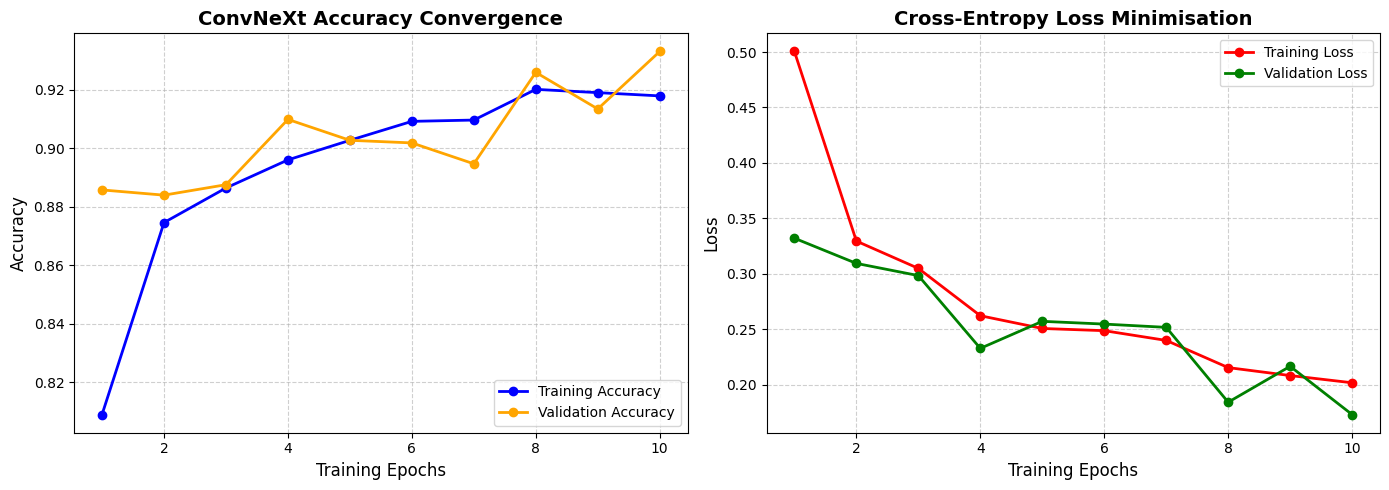

In [111]:
print("Generating Learning Curves for ConvNeXt...")

# GENERATE VISUALS
plt.figure(figsize=(14, 5))

# Accuracy Convergence Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_accuracies, label='Training Accuracy', marker='o', color='blue', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_accuracies, label='Validation Accuracy', marker='o', color='orange', linewidth=2)
plt.title('ConvNeXt Accuracy Convergence', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Minimisation Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_losses, label='Training Loss', marker='o', color='red', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', marker='o', color='green', linewidth=2)
plt.title('Cross-Entropy Loss Minimisation', fontsize=14, weight='bold')
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Save and Show: Learning Curves
plt.savefig(os.path.join(png_dir, 'convnext_learning_curves.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'convnext_learning_curves.svg'), format='svg', bbox_inches='tight')
plt.show()

### FINAL ConvNeXt MODEL TESTING

In [112]:
print("\n--- Starting ConvNeXt Model Testing ---")

# Explicitly load the peak checkpoint file
convnext.load_state_dict(torch.load(model_save_path_conv))
convnext.eval()

test_loss, correct_test, total_test = 0.0, 0, 0
all_preds_conv = []
all_labels_conv = []

# Inference time tracking
conv_total_inference_time = 0.0

print(f"Running Inference on Unseen Testing Set ({len(test_dataset)} images)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        outputs = convnext(inputs)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        conv_total_inference_time += (end_time - start_time)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_preds_conv.extend(predicted.cpu().numpy())
        all_labels_conv.extend(labels.cpu().numpy())

test_accuracy_conv = correct_test / total_test
conv_avg_latency_ms = (conv_total_inference_time / total_test) * 1000

print(f"\nCONVNEXT FINAL TEST ACCURACY: {test_accuracy_conv * 100:.2f}%\n")
print(f"CONVNEXT Total GPU Inference Time: {conv_total_inference_time:.4f} seconds")
print(f"CONVNEXT Average Inference Latency per Scan: {conv_avg_latency_ms:.2f} milliseconds\n")


--- Starting ConvNeXt Model Testing ---
Running Inference on Unseen Testing Set (1600 images)...

CONVNEXT FINAL TEST ACCURACY: 89.75%

CONVNEXT Total GPU Inference Time: 19.7187 seconds
CONVNEXT Average Inference Latency per Scan: 12.32 milliseconds



### FINAL ConvNeXt MODEL CLINICAL EVALUATION

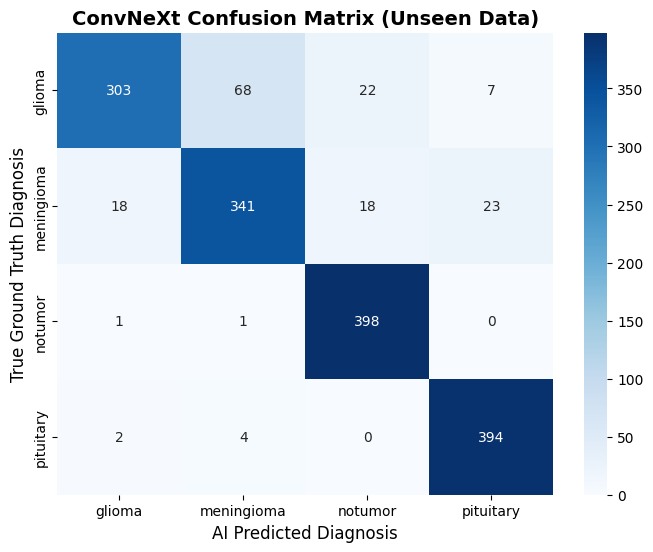


--- ConvNeXt Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.94      0.76      0.84       400
  meningioma       0.82      0.85      0.84       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.93      0.98      0.96       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [113]:
# The Confusion Matrix Plot
cm_conv = confusion_matrix(all_labels_conv, all_preds_conv)
class_names = test_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm_conv, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ConvNeXt Confusion Matrix (Unseen Data)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the final thesis visual
plt.savefig(os.path.join(png_dir, 'convnext_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'convnext_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

# The Classification Report
print("\n--- ConvNeXt Detailed Clinical Classification Report ---")
print(classification_report(all_labels_conv, all_preds_conv, target_names=class_names))

---
# ENSEMBLING
---

### Pairwise Ensemble

In [114]:
print("--- Initializing The Pairwise Ensemble Matrix ---")

# Ensure all models are loaded with their Baseline V1 weights
# (Assuming your models are still in memory from the previous cells.
# If not, add the torch.load() lines here for safety)
models_dict = {
    'ResNet-50': resnet50,
    'EfficientNet-B0': efficientnet,
    'ViT-Base': vit,
    'Swin Transformer': swin,
    'ConvNeXt': convnext
}

# Lock all brains for evaluation
for name, model in models_dict.items():
    model.eval()

# Dictionaries to store the raw probability scores for the entire test set
all_probs = {name: [] for name in models_dict.keys()}
true_labels = []

print(f"Executing Single-Pass GPU Inference on Testing Set ({len(test_dataset)} images)...")
print("Extracting raw probabilities. This will take a few minutes...")

# THE SINGLE PASS (Extracting probabilities efficiently)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        # Store true labels
        true_labels.extend(labels.numpy())

        # Extract and apply Softmax to get probabilities (0.0 to 1.0) for each model
        for name, model in models_dict.items():
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Convert raw logits to percentages
            all_probs[name].extend(probs.cpu().numpy())

# Convert lists to NumPy arrays for lightning-fast matrix math
for name in models_dict.keys():
    all_probs[name] = np.array(all_probs[name])
true_labels = np.array(true_labels)

print("Inference complete. Calculating Soft-Voting metrics for all 10 combinations...\n")

# GENERATING ALL PAIRWISE COMBINATIONS
model_names = list(models_dict.keys())
combinations = list(itertools.combinations(model_names, 2))

# List to store leaderboard results
leaderboard_data = []

# EVALUATING THE ENSEMBLES (CORRECTED FOR ALL 4 CLASSES)
for model_a, model_b in combinations:
    # Soft Voting: Average the probabilities of the two models
    ensemble_probs = (all_probs[model_a] + all_probs[model_b]) / 2.0

    # The final prediction is the class with the highest average probability
    ensemble_preds = np.argmax(ensemble_probs, axis=1)

    # Calculate Core Metrics
    acc = accuracy_score(true_labels, ensemble_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, ensemble_preds, average='macro', zero_division=0)

    # Calculate specific Recalls for all 4 classes
    # ImageFolder naturally sorts alphabetically: 0=glioma, 1=meningioma, 2=notumor, 3=pituitary
    _, class_recalls, _, _ = precision_recall_fscore_support(true_labels, ensemble_preds, labels=[0, 1, 2, 3], zero_division=0)

    leaderboard_data.append({
        'Ensemble Pair': f"{model_a} + {model_b}",
        'Overall Acc': acc * 100,
        'Macro F1': f1 * 100,
        'Glioma': class_recalls[0] * 100,
        'Meningioma': class_recalls[1] * 100,
        'Notumor': class_recalls[2] * 100,
        'Pituitary': class_recalls[3] * 100
    })

# BUILDING THE COMPLETE LEADERBOARD
leaderboard_df = pd.DataFrame(leaderboard_data)
# Sort by Highest Overall Accuracy
leaderboard_df = leaderboard_df.sort_values(by=['Overall Acc'], ascending=[False]).reset_index(drop=True)

print("=================================================================================================")
print("                                 COMPLETE ENSEMBLE LEADERBOARD                                   ")
print("=================================================================================================")
# Print formatted DataFrame ensuring no columns are hidden
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(leaderboard_df.to_string(index=True, float_format=lambda x: f"{x:.2f}%"))
print("=================================================================================================")

# Save to CSV for your methodology chapter
csv_path = os.path.join(BASE_DIR, 'logs', 'ensemble_leaderboard.csv')
leaderboard_df.to_csv(csv_path, index=False)
print(f"\nComplete Leaderboard successfully saved to {csv_path}")

--- Initializing The Pairwise Ensemble Matrix ---
Executing Single-Pass GPU Inference on Testing Set (1600 images)...
Extracting raw probabilities. This will take a few minutes...
Inference complete. Calculating Soft-Voting metrics for all 10 combinations...

                                 COMPLETE ENSEMBLE LEADERBOARD                                   
                        Ensemble Pair  Overall Acc  Macro F1  Glioma  Meningioma  Notumor  Pituitary
0         ViT-Base + Swin Transformer       93.31%    93.24%  80.50%      95.25%   99.75%     97.75%
1                 ViT-Base + ConvNeXt       92.81%    92.69%  78.75%      95.25%  100.00%     97.25%
2                ResNet-50 + ViT-Base       92.25%    92.12%  77.25%      95.25%  100.00%     96.50%
3          EfficientNet-B0 + ViT-Base       91.94%    91.81%  75.75%      95.75%  100.00%     96.25%
4         Swin Transformer + ConvNeXt       90.88%    90.73%  76.50%      90.25%   99.25%     97.50%
5  EfficientNet-B0 + Swin Transforme

### Evaluating Champion Ensemble


--- Executing Unweighted Soft-Voting (ViT-Base + Swin Transformer) ---

  FINAL CHAMPION ENSEMBLE TEST ACCURACY: 93.31%

--- Final Champion Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.97      0.81      0.88       400
  meningioma       0.84      0.95      0.89       400
     notumor       0.96      1.00      0.98       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



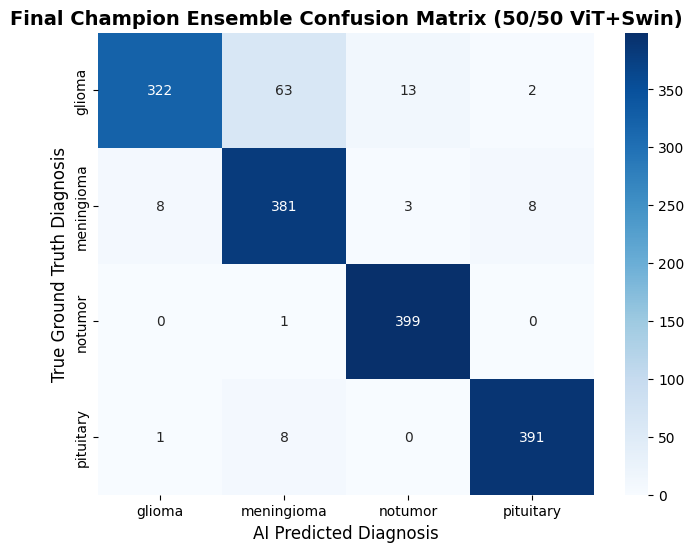


Final evaluation complete. Champion Confusion Matrix saved for thesis.


In [115]:
# --- EVALUATING THE 50/50 CHAMPION ---
print("\n--- Executing Unweighted Soft-Voting (ViT-Base + Swin Transformer) ---")
champion_probs = (all_probs['ViT-Base'] + all_probs['Swin Transformer']) / 2.0
champion_preds = np.argmax(champion_probs, axis=1)

final_acc = accuracy_score(true_labels, champion_preds)
print(f"\n==========================================================")
print(f"  FINAL CHAMPION ENSEMBLE TEST ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================================\n")

class_names = test_dataset.classes
print("--- Final Champion Detailed Clinical Classification Report ---")
print(classification_report(true_labels, champion_preds, target_names=class_names))

# PLOT AND SAVE THE CHAMPION CONFUSION MATRIX
cm_final = confusion_matrix(true_labels, champion_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Final Champion Ensemble Confusion Matrix (50/50 ViT+Swin)', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

plt.savefig(os.path.join(png_dir, 'final_champion_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'final_champion_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

print("\nFinal evaluation complete. Champion Confusion Matrix saved for thesis.")

## Class-Specific Weighted Ensemble

--- Executing Class-Specific Weighted Ensemble ---
ViT-Base Class Weights: [1.  0.4 0.5 0.5]
Swin Transform Class Weights: [0.  0.6 0.5 0.5]

  CLASS-SPECIFIC ENSEMBLE TEST ACCURACY: 93.25%

Macro F1-Score (Fairness): 93.17%
Glioma Recall: 80.75%
Meningioma Recall: 94.50%
Notumor Recall: 99.75%
Pituitary Recall: 98.00%

--- Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.97      0.81      0.88       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.96      1.00      0.98       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



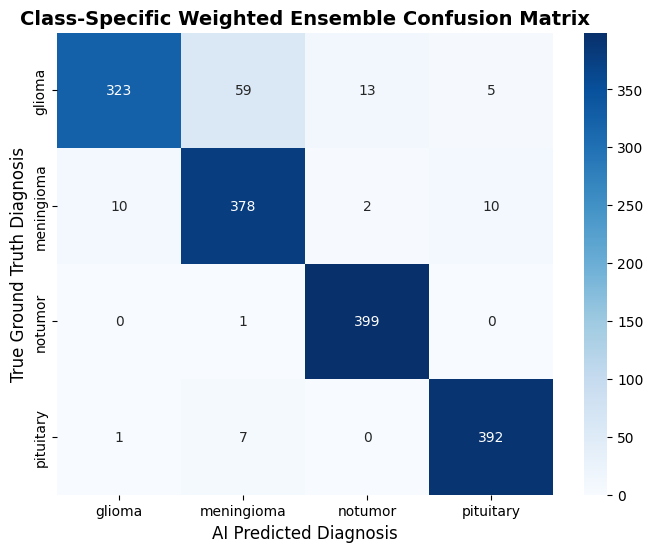


Evaluation complete. Class-Specific Confusion Matrix saved successfully.


In [116]:
print("--- Executing Class-Specific Weighted Ensemble ---")

# DEFINE THE SPECIALIST MATRICES
# Order: [Glioma, Meningioma, Notumor, Pituitary]
# We give ViT 100% voting power on Gliomas to prevent dilution.
# We give Swin 60% voting power on Meningiomas because it excels in this area.
# We leave Notumor and Pituitary at a 50/50 baseline.

weight_matrix_vit =  np.array([1.00, 0.40, 0.50, 0.50])
weight_matrix_swin = np.array([0.00, 0.60, 0.50, 0.50])

print(f"ViT-Base Class Weights: {weight_matrix_vit}")
print(f"Swin Transform Class Weights: {weight_matrix_swin}")

# APPLY THE ELEMENT-WISE MATRIX MULTIPLICATION
# This scales the probabilities for each class independently based on the model's expertise
specialist_probs = (all_probs['ViT-Base'] * weight_matrix_vit) + (all_probs['Swin Transformer'] * weight_matrix_swin)

# EXTRACT PREDICTIONS
specialist_preds = np.argmax(specialist_probs, axis=1)

# EVALUATE AGAINST STANDALONE BENCHMARK
final_acc = accuracy_score(true_labels, specialist_preds)
_, _, f1, _ = precision_recall_fscore_support(true_labels, specialist_preds, average='macro', zero_division=0)
_, class_recalls, _, _ = precision_recall_fscore_support(true_labels, specialist_preds, labels=[0, 1, 2, 3], zero_division=0)

print(f"\n==========================================================")
print(f"  CLASS-SPECIFIC ENSEMBLE TEST ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================================\n")

print(f"Macro F1-Score (Fairness): {f1 * 100:.2f}%")
print(f"Glioma Recall: {class_recalls[0] * 100:.2f}%")
print(f"Meningioma Recall: {class_recalls[1] * 100:.2f}%")
print(f"Notumor Recall: {class_recalls[2] * 100:.2f}%")
print(f"Pituitary Recall: {class_recalls[3] * 100:.2f}%")

class_names = test_dataset.classes
print("\n--- Detailed Clinical Classification Report ---")
print(classification_report(true_labels, specialist_preds, target_names=class_names))

# GENERATE AND SAVE THE MASTER CONFUSION MATRIX
cm_specialist = confusion_matrix(true_labels, specialist_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_specialist, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Class-Specific Weighted Ensemble Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the files for thesis/logs
plt.savefig(os.path.join(png_dir, 'specialist_ensemble_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'specialist_ensemble_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

print("\nEvaluation complete. Class-Specific Confusion Matrix saved successfully.")

## 60/40 Weighted Soft-Voting Ensemble

--- Executing Final 60/40 Weighted Soft-Voting Ensemble ---
Applying weights: ViT-Base (60.0%) + Swin Transformer (40.0%)

  FINAL WEIGHTED ENSEMBLE TEST ACCURACY: 93.31%

--- Final Champion Detailed Clinical Classification Report ---
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.89       400
  meningioma       0.84      0.95      0.89       400
     notumor       0.96      1.00      0.98       400
   pituitary       0.97      0.97      0.97       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



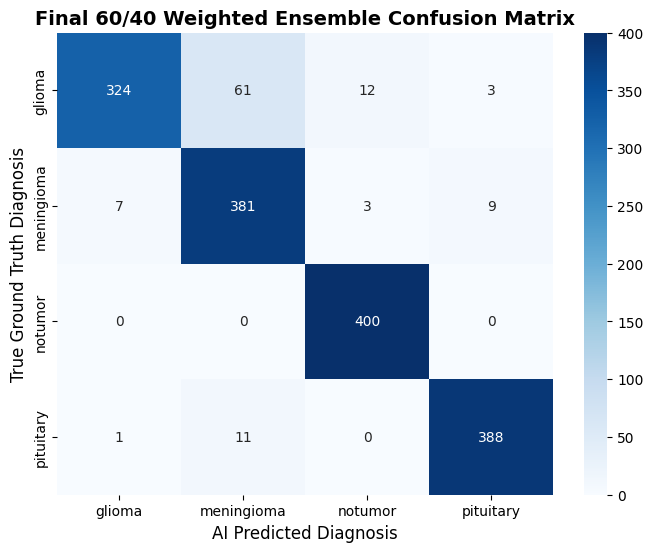


Final evaluation complete. Champion Confusion Matrix saved successfully.


In [117]:
print("--- Executing Final 60/40 Weighted Soft-Voting Ensemble ---")

# Apply the Golden Ratio weights to the saved probability arrays
w_vit = 0.60
w_swin = 0.40

print(f"Applying weights: ViT-Base ({w_vit*100}%) + Swin Transformer ({w_swin*100}%)")
final_weighted_probs = (w_vit * all_probs['ViT-Base']) + (w_swin * all_probs['Swin Transformer'])

# Extract the final predictions (the class with the highest weighted percentage)
final_weighted_preds = np.argmax(final_weighted_probs, axis=1)

# Calculate Overall Accuracy
final_acc = accuracy_score(true_labels, final_weighted_preds)
print(f"\n==========================================================")
print(f"  FINAL WEIGHTED ENSEMBLE TEST ACCURACY: {final_acc * 100:.2f}%")
print(f"==========================================================\n")

# Generate the Detailed Classification Report
class_names = test_dataset.classes
print("--- Final Champion Detailed Clinical Classification Report ---")
print(classification_report(true_labels, final_weighted_preds, target_names=class_names))

# Generate and Save the Confusion Matrix
cm_final = confusion_matrix(true_labels, final_weighted_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Final 60/40 Weighted Ensemble Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.ylabel('True Ground Truth Diagnosis', fontsize=12)

# Save the visual
plt.savefig(os.path.join(png_dir, 'final_champion_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(svg_dir, 'final_champion_confusion_matrix.svg'), format='svg', bbox_inches='tight')
plt.show()

print("\nFinal evaluation complete. Champion Confusion Matrix saved successfully.")

### CHAMPION ENSEMBLE INFERENCE BENCHMARKING

In [118]:
print("\n--- Benchmarking 60/40 Ensemble Inference Latency ---")

# Lock the champion models
vit.eval()
swin.eval()

ensemble_total_inference_time = 0.0
total_test_samples = 0

print("Simulating real-world deployment latency (Sequential ViT + Swin forward passes)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.time()

        # Forward pass through ViT
        out_vit = vit(inputs)

        # Forward pass through Swin
        out_swin = swin(inputs)

        # Softmax and 60/40 Weighted Fusion
        prob_vit = F.softmax(out_vit, dim=1)
        prob_swin = F.softmax(out_swin, dim=1)
        final_probs = (0.60 * prob_vit) + (0.40 * prob_swin)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.time()

        ensemble_total_inference_time += (end_time - start_time)
        total_test_samples += inputs.size(0)

ensemble_avg_latency_ms = (ensemble_total_inference_time / total_test_samples) * 1000

print(f"60/40 ENSEMBLE Total GPU Inference Time: {ensemble_total_inference_time:.4f} seconds")
print(f"60/40 ENSEMBLE Average Inference Latency per Scan: {ensemble_avg_latency_ms:.2f} milliseconds\n")


--- Benchmarking 60/40 Ensemble Inference Latency ---
Simulating real-world deployment latency (Sequential ViT + Swin forward passes)...
60/40 ENSEMBLE Total GPU Inference Time: 43.1808 seconds
60/40 ENSEMBLE Average Inference Latency per Scan: 26.99 milliseconds



### INFERENCE LATENCY COMPARISON TABLE

In [119]:
print("--- Final Architectural Inference Latency Comparison ---")

# Aggregate all previously calculated latency variables
latency_data = {
    "Architecture": [
        "EfficientNet-B0 (CNN)",
        "ResNet-50 (CNN)",
        "ConvNeXt-Base (CNN)",
        "Swin Transformer (ViT)",
        "ViT-Base (ViT)",
        "60/40 Champion Ensemble (ViT+Swin)"
    ],
    "Avg Inference Time (ms/scan)": [
        eff_avg_latency_ms,
        res_avg_latency_ms,
        conv_avg_latency_ms,
        swin_avg_latency_ms,
        vit_avg_latency_ms,
        ensemble_avg_latency_ms
    ]
}

# Create DataFrame and sort from fastest to slowest
latency_df = pd.DataFrame(latency_data)
latency_df = latency_df.sort_values(by="Avg Inference Time (ms/scan)", ascending=True).reset_index(drop=True)

# Format the output for clean visual reading
latency_df["Avg Inference Time (ms/scan)"] = latency_df["Avg Inference Time (ms/scan)"].apply(lambda x: f"{x:.2f} ms")

# Display the formatted table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(latency_df.to_string(index=True))

# Save the table to the logs folder for your thesis
latency_csv_path = os.path.join(BASE_DIR, 'logs', 'inference_latency_comparison.csv')
latency_df.to_csv(latency_csv_path, index=False)
print(f"\nLatency comparison table successfully saved to {latency_csv_path}")

--- Final Architectural Inference Latency Comparison ---
                         Architecture Avg Inference Time (ms/scan)
0               EfficientNet-B0 (CNN)                      1.38 ms
1                     ResNet-50 (CNN)                      3.12 ms
2                 ConvNeXt-Base (CNN)                     12.32 ms
3                      ViT-Base (ViT)                     12.72 ms
4              Swin Transformer (ViT)                     13.89 ms
5  60/40 Champion Ensemble (ViT+Swin)                     26.99 ms

Latency comparison table successfully saved to /content/drive/MyDrive/Brain_MRI_Triage_System/logs/inference_latency_comparison.csv


---
# EXPLAINABLE AI
---

--- Initializing Vision Transformer Attention Maps (XAI) ---


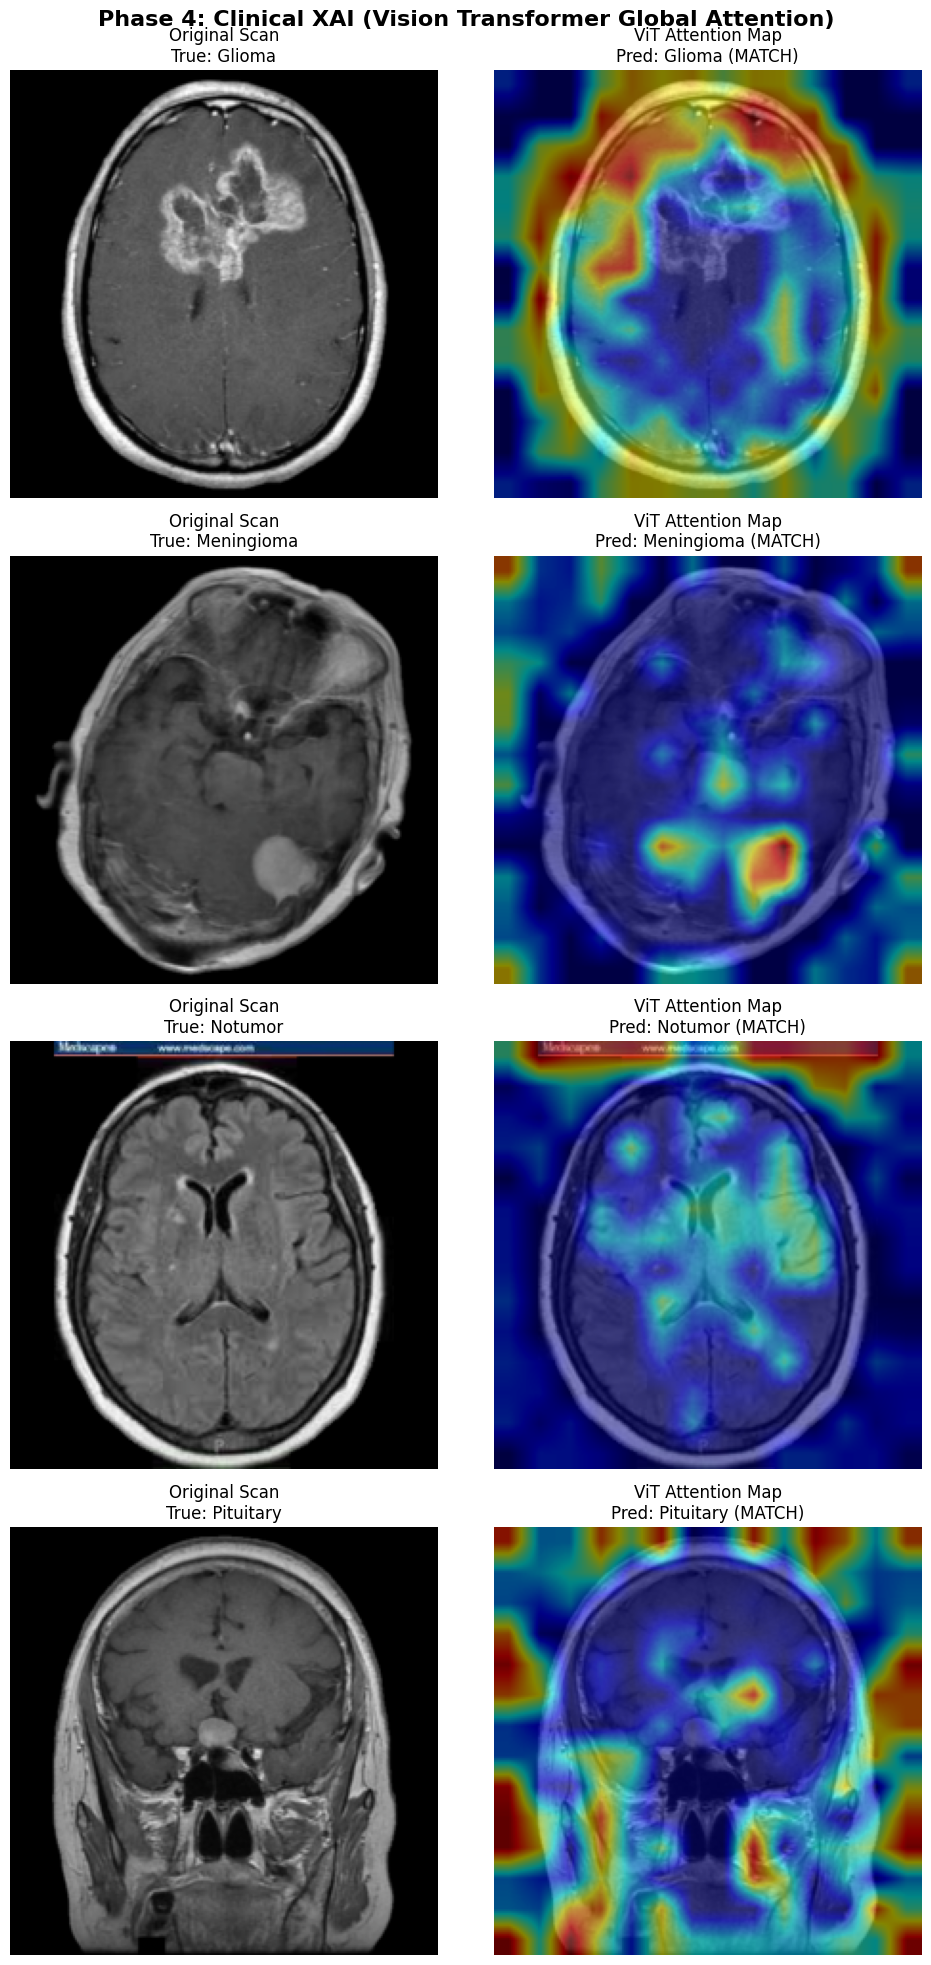


Visual Explainability heatmaps successfully generated and saved to /content/drive/MyDrive/Brain_MRI_Triage_System/visuals/png/vit_attention_maps.png


In [120]:
print("--- Initializing Vision Transformer Attention Maps (XAI) ---")

# --- UNFREEZE THE MODEL FOR XAI GRADIENTS ---
for param in vit.parameters():
    param.requires_grad = True

# DEFINE THE RESHAPE FUNCTION FOR ViT
# Transformers output a 1D sequence of patches. We must mathematically reshape
# them back into a 2D 14x14 grid so they can be overlaid on the MRI.
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# TARGET THE FINAL ATTENTION BLOCK
# We hook into the very last layer of the ViT-Base encoder to see its final decision.
target_layers = [vit.encoder.layers[-1].ln_1]

# Initialize the XAI Engine
cam = GradCAM(model=vit, target_layers=target_layers, reshape_transform=reshape_transform)

# SELECT ONE SAMPLE IMAGE FROM EACH CLASS
sample_indices = []
classes_found = set()

for i, (_, label) in enumerate(test_dataset):
    if label not in classes_found:
        sample_indices.append(i)
        classes_found.add(label)
    if len(classes_found) == 4:
        break

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle('Phase 4: Clinical XAI (Vision Transformer Global Attention)', fontsize=16, weight='bold')
class_names = test_dataset.classes

# GENERATE AND OVERLAY THE HEATMAPS
for row, idx in enumerate(sample_indices):
    input_tensor, label = test_dataset[idx]

    # Format input for the model
    input_batch = input_tensor.unsqueeze(0).to(device)

    # Get the model's prediction
    vit.eval()
    with torch.no_grad():
        output = vit(input_batch)
        pred_label = torch.argmax(output, dim=1).item()

    # Generate the Heatmap targeting the predicted class
    targets = [ClassifierOutputTarget(pred_label)]
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0, :]

    # Re-format the original image for plotting (un-normalize it)
    img_viz = input_tensor.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_viz = std * img_viz + mean
    img_viz = np.clip(img_viz, 0, 1) # Ensure valid RGB range

    # Overlay the heatmap (Red = High Attention, Blue = Low Attention)
    visualization = show_cam_on_image(img_viz, grayscale_cam, use_rgb=True, colormap=cv2.COLORMAP_JET)

    # Plot Original Scan
    axes[row, 0].imshow(img_viz)
    axes[row, 0].set_title(f"Original Scan\nTrue: {class_names[label].capitalize()}")
    axes[row, 0].axis('off')

    # Plot XAI Heatmap
    match_status = "MATCH" if label == pred_label else "MISS"
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title(f"ViT Attention Map\nPred: {class_names[pred_label].capitalize()} ({match_status})")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)

# Save the final thesis visual
xai_save_path = os.path.join(png_dir, 'vit_attention_maps.png')
plt.savefig(xai_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisual Explainability heatmaps successfully generated and saved to {xai_save_path}")

--- Step 2: Generating Vision Transformer Attention Maps (XAI) ---


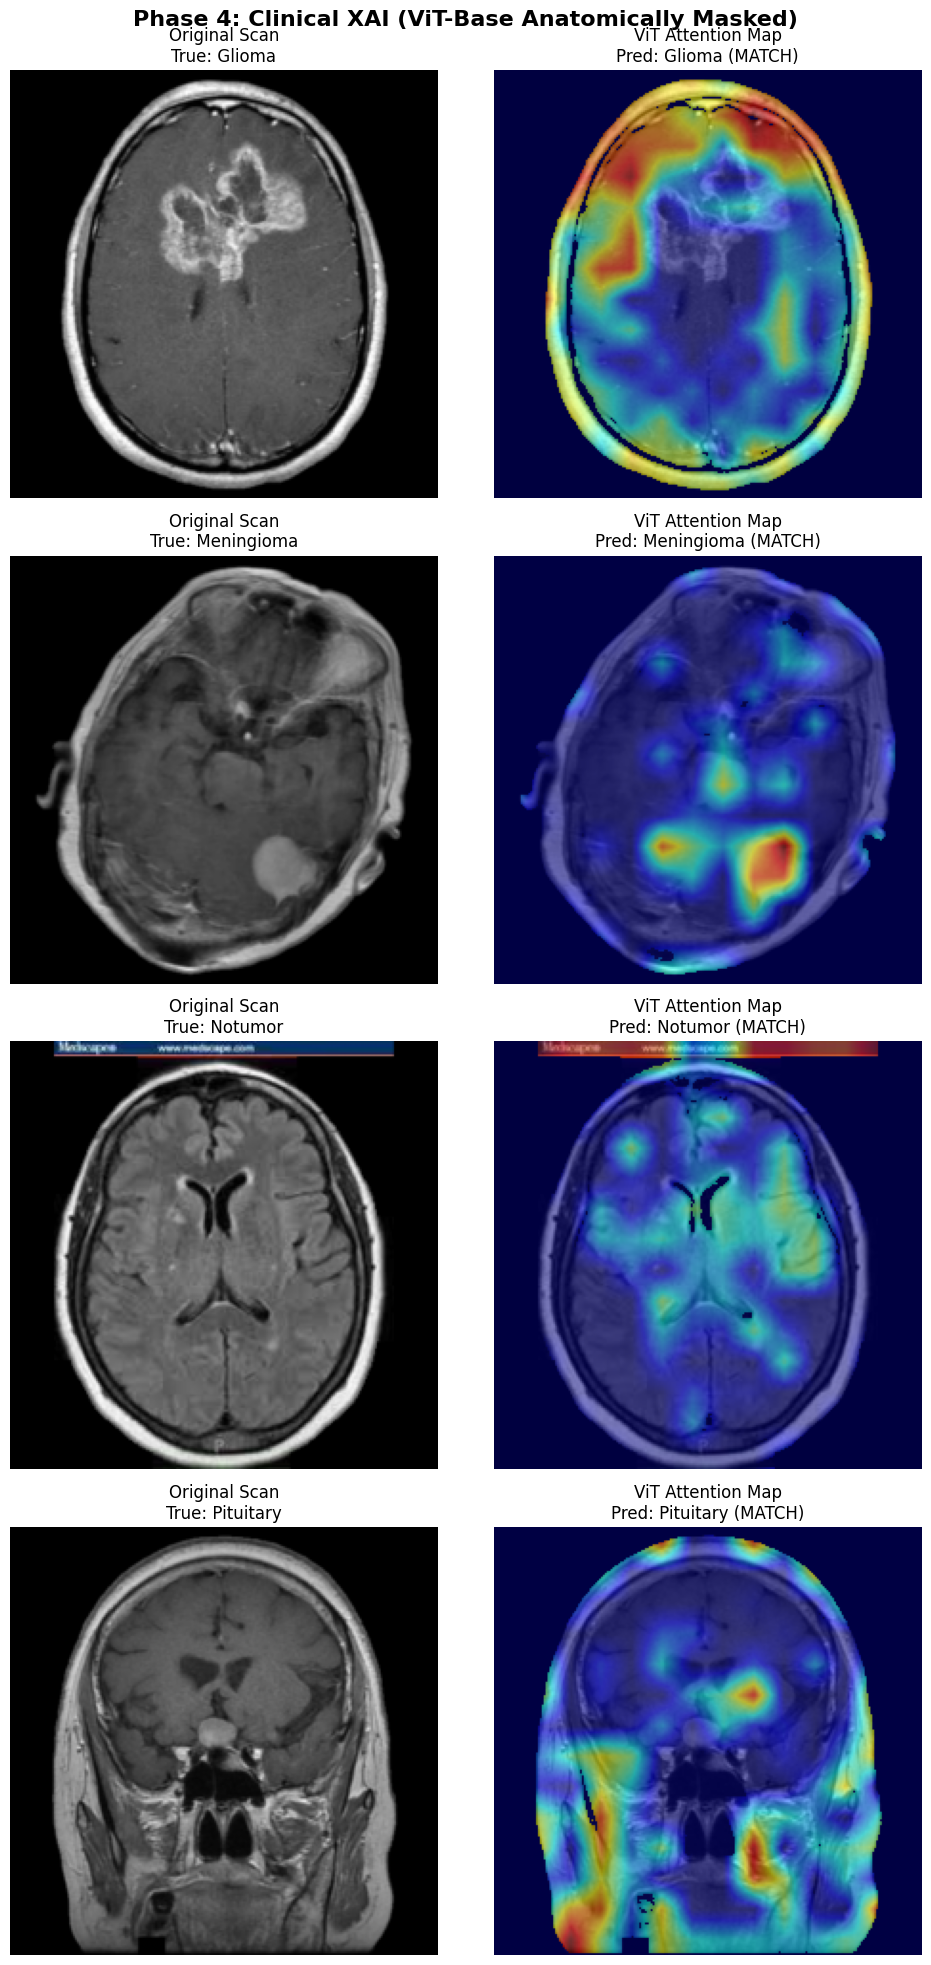


Masked heatmaps successfully generated and saved to /content/drive/MyDrive/Brain_MRI_Triage_System/visuals/png/vit_attention_maps_masked.png


In [121]:
print("--- Step 2: Generating Vision Transformer Attention Maps (XAI) ---")

# DEFINE THE RESHAPE FUNCTION FOR ViT
def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

# TARGET THE FINAL ATTENTION BLOCK
target_layers = [vit.encoder.layers[-1].ln_1]
cam = GradCAM(model=vit, target_layers=target_layers, reshape_transform=reshape_transform)

# SELECT ONE SAMPLE IMAGE FROM EACH CLASS
sample_indices = []
classes_found = set()

for i, (_, label) in enumerate(test_dataset):
    if label not in classes_found:
        sample_indices.append(i)
        classes_found.add(label)
    if len(classes_found) == 4:
        break

fig, axes = plt.subplots(4, 2, figsize=(10, 20))
fig.suptitle('Phase 4: Clinical XAI (ViT-Base Anatomically Masked)', fontsize=16, weight='bold')
class_names = test_dataset.classes

# GENERATE AND OVERLAY THE HEATMAPS
for row, idx in enumerate(sample_indices):
    input_tensor, label = test_dataset[idx]

    input_batch = input_tensor.unsqueeze(0).to(device)

    vit.eval()
    with torch.no_grad():
        output = vit(input_batch)
        pred_label = torch.argmax(output, dim=1).item()

    targets = [ClassifierOutputTarget(pred_label)]

    # Generate Heatmap
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0, :]

    # Re-format the original image for plotting
    img_viz = input_tensor.permute(1, 2, 0).numpy()

    # --- THE FIX: FORCE 32-BIT FLOATS TO KEEP OPENCV HAPPY ---
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_viz = std * img_viz + mean
    img_viz = np.clip(img_viz, 0, 1).astype(np.float32)
    # ---------------------------------------------------------

    # --- ANATOMICAL MASKING ---
    # Convert image to grayscale to find the black background
    gray_img = cv2.cvtColor(img_viz, cv2.COLOR_RGB2GRAY)
    # Create a strict binary mask: if it's practically black (background), it becomes 0. If it's brain, it becomes 1.
    _, mask = cv2.threshold((gray_img * 255).astype(np.uint8), 15, 1, cv2.THRESH_BINARY)
    # Multiply the Grad-CAM heatmap by the mask to kill background noise
    clean_cam = grayscale_cam * mask
    # -----------------------------------

    # Render using the clean, masked CAM
    visualization = show_cam_on_image(img_viz, clean_cam, use_rgb=True, colormap=cv2.COLORMAP_JET)

    axes[row, 0].imshow(img_viz)
    axes[row, 0].set_title(f"Original Scan\nTrue: {class_names[label].capitalize()}")
    axes[row, 0].axis('off')

    match_status = "MATCH" if label == pred_label else "MISS"
    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title(f"ViT Attention Map\nPred: {class_names[pred_label].capitalize()} ({match_status})")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)

xai_save_path_png = os.path.join(png_dir, 'vit_attention_maps_masked.png')
xai_save_path_svg = os.path.join(svg_dir, 'vit_attention_maps_masked.svg')
plt.savefig(xai_save_path_png, dpi=300, bbox_inches='tight')
plt.savefig(xai_save_path_svg, format='svg', bbox_inches='tight')
plt.show()

print(f"\nMasked heatmaps successfully generated and saved to {xai_save_path_png}")